In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [38]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())

label
0    18399879
1      100118
Name: count, dtype: int64


In [39]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df, on="label_id", how="inner")
print(logsum_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
15992331    NR_184306:85   1.133184      0.000000        0.000000          0   
15992332    NR_184306:87   3.771550     -0.001452       -2.476578          1   
15992333    NR_184306:88   2.137289      0.000000        0.000000          0   
15992334    NR_184306:93  32.341377     -0.011076      -78.301079         23   
15992335    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [40]:
dorado_080_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/dorado-080/ON0090_dorado_basecall.bed" + ".m6A.pkl")
dorado_080_df.rename(columns = {"count_dom": "dorado_count", "dom": "pred_dorado"}, inplace = True)
dorado_080_df = dorado_080_df[dorado_080_df["dorado_count"] >= 20]
dorado_080_df = dorado_080_df.merge(label_df, on="label_id", how="inner")
dorado_080_df = dorado_080_df[["pred_dorado", "dorado_count", "label_id"]]
print(dorado_080_df)    

          pred_dorado  dorado_count       label_id
0              0.0161            62    NM_000016:2
1              0.0149            67    NM_000016:5
2              0.0125           160   NM_000016:21
3              0.0616           146   NM_000016:24
4              0.0412           170   NM_000016:29
...               ...           ...            ...
15312228       0.1463            41  NR_184306:326
15312229       0.0000            40  NR_184306:330
15312230       0.0233            43  NR_184306:331
15312231       0.0000            43  NR_184306:333
15312232       0.0938            32  NR_184306:334

[15312233 rows x 3 columns]


In [41]:
dorado_080_df.rename(columns = {"dorado_count": "dorado_count_080", "pred_dorado": "pred_dorado_080"}, inplace = True)
eval_df = logsum_df.merge(dorado_080_df, on="label_id", how="left").fillna(0)
print(eval_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
15992369    NR_184306:85   1.133184      0.000000        0.000000          0   
15992370    NR_184306:87   3.771550     -0.001452       -2.476578          1   
15992371    NR_184306:88   2.137289      0.000000        0.000000          0   
15992372    NR_184306:93  32.341377     -0.011076      -78.301079         23   
15992373    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [42]:
eval_df["pm6a"] =  -(2-eval_df["dom"])*eval_df["logsum_1_p_pos"]/eval_df["count_all"] + ((1-eval_df["dom"])*np.log10(np.clip(1-eval_df["dom"],1e-30,1)) + eval_df["dom"] * np.log10(np.clip(eval_df["dom"],1e-30,1)))*(eval_df["count_pos"]/eval_df["count_all"])

print(eval_df[['pm6a', 'dom', 'count_dom', 'count_all', '5mer', 'drach', 'pred_dorado_080', 'dorado_count_080']])

              pm6a       dom  count_dom  count_all   5mer  drach  \
0         0.000000  0.000000        258        258  AAACT   True   
1         0.000000  0.000000        256        257  GGAAA  False   
2        -0.000000  0.003891        257        260  GAAAG  False   
3        -0.000000  0.011583        259        263  AAAGC  False   
4         0.000000  0.000000        252        258  CTACT  False   
...            ...       ...        ...        ...    ...    ...   
15992369  0.000000  0.000000         49         51  TTATA  False   
15992370  0.092186  0.061224         49         51  ATAAT  False   
15992371 -0.000000  0.039216         51         51  TAATC  False   
15992372  1.919874  0.695652         46         50  GGACT   True   
15992373  0.000000  0.000000         40         48  TCAGC  False   

          pred_dorado_080  dorado_count_080  
0                  0.0076             263.0  
1                  0.0000             262.0  
2                  0.0039             257.0  

In [43]:

geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
geneid_table.rename({"transcript_id":"refseq"}, axis=1, inplace=True)
print(geneid_table)

              gene_id        refseq
6             DDX11L1     NR_046018
11             WASH7P     NR_024540
24          MIR6859-1     NR_106918
31        MIR1302-2HG  XR_007065314
36          MIR1302-2     NR_036051
...               ...           ...
4683855     KIR2DS5_6  XM_054333504
4683875    KIR2DL5A_7  XM_054333508
4683946     KIR3DS1_9  XM_054333507
4683987  LOC128966733  XR_008485847
4683991  LOC128966733  XM_054333509

[184489 rows x 2 columns]


In [44]:
eval_df["refseq"] = eval_df["label_id"].str.split(":").str[0]
eval_df = eval_df.merge(geneid_table, on="refseq", how="left")
eval_df.rename(columns = {"pm6a": "log_pm6a", "pred_dorado_080": "pred_dorado", "dorado_count_080": "count_dorado"}, inplace=True)
print(eval_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
15992369    NR_184306:85   1.133184      0.000000        0.000000          0   
15992370    NR_184306:87   3.771550     -0.001452       -2.476578          1   
15992371    NR_184306:88   2.137289      0.000000        0.000000          0   
15992372    NR_184306:93  32.341377     -0.011076      -78.301079         23   
15992373    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [45]:
ivt_tpm_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/tpm/tpm.tsv",sep="\t")
ivt_tpm_df = ivt_tpm_df[ivt_tpm_df["tpm"] > 0.0]
ivt_tpm_df["logtpm"] = np.log10(ivt_tpm_df["tpm"])
ivt_tpm_df["refseq"] = ivt_tpm_df["transcript_name"].str.split(".").str[0]
ivt_tpm_df["ivt_perc"] = ivt_tpm_df["logtpm"].rank(pct=True)
ivt_tpm_df

,transcript_name,raw,est_count,tpm,transcript_length,logtpm,refseq,ivt_perc
0,NM_002952.4,1.339165e-02,1.840900e+04,1.339165e+04,945,4.126834,NM_002952,1.000000
1,NR_026712.1,1.118017e-02,1.536897e+04,1.118017e+04,658,4.048449,NR_026712,0.999981
2,NM_001000.4,9.515059e-03,1.308000e+04,9.515059e+03,390,3.978411,NM_001000,0.999961
3,NM_022551.3,9.240792e-03,1.270297e+04,9.240792e+03,549,3.965709,NM_022551,0.999942
4,NM_001404.5,9.131693e-03,1.255300e+04,9.131693e+03,1446,3.960551,NM_001404,0.999922
...,...,...,...,...,...,...,...,...
51536,NR_024240.1,3.105177e-40,4.268573e-34,3.105177e-34,1580,-33.507914,NR_024240,0.000097
51537,NR_024219.1,6.239105e-49,8.576667e-43,6.239105e-43,120,-42.204878,NR_024219,0.000058
51538,NR_024217.1,6.239105e-49,8.576667e-43,6.239105e-43,120,-42.204878,NR_024217,0.000058
51539,NR_024220.1,6.239105e-49,8.576667e-43,6.239105e-43,120,-42.204878,NR_024220,0.000058


In [46]:
cell_tpm_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/tpm/tpm.tsv",sep="\t")
cell_tpm_df = cell_tpm_df[cell_tpm_df["tpm"] > 0.0]
cell_tpm_df["logtpm"] = np.log10(cell_tpm_df["tpm"])
cell_tpm_df["refseq"] = cell_tpm_df["transcript_name"].str.split(".").str[0]
cell_tpm_df["cell_perc"] = cell_tpm_df["logtpm"].rank(pct=True)
cell_tpm_df

,transcript_name,raw,est_count,tpm,transcript_length,logtpm,refseq,cell_perc
0,NM_002952.4,1.124904e-02,4.911100e+04,1.124904e+04,945,4.051116,NM_002952,1.000000
1,NM_022551.3,6.785937e-03,2.962600e+04,6.785937e+03,549,3.831610,NM_022551,0.999984
2,NM_001000.4,6.460679e-03,2.820599e+04,6.460679e+03,390,3.810278,NM_001000,0.999967
3,NM_000972.3,5.957222e-03,2.600800e+04,5.957222e+03,887,3.775044,NM_000972,0.999951
4,NR_026712.1,5.942332e-03,2.594299e+04,5.942332e+03,658,3.773957,NR_026712,0.999934
...,...,...,...,...,...,...,...,...
60667,NM_001395980.1,7.291763e-45,3.183433e-38,7.291763e-39,1559,-38.137167,NM_001395980,0.000082
60668,NR_001434.4,2.219039e-46,9.687866e-40,2.219039e-40,1705,-39.653835,NR_001434,0.000066
60669,NR_144546.2,9.444820e-51,4.123413e-44,9.444820e-45,1456,-44.024806,NR_144546,0.000041
60670,NR_176224.1,9.444820e-51,4.123413e-44,9.444820e-45,1414,-44.024806,NR_176224,0.000041


In [47]:
eval_df = eval_df.merge(ivt_tpm_df[["refseq", "ivt_perc"]], on="refseq", how="left")
eval_df = eval_df.merge(cell_tpm_df[["refseq", "cell_perc"]], on="refseq", how="left")
eval_df.fillna(0, inplace=True)
print(eval_df)


                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
15992369    NR_184306:85   1.133184      0.000000        0.000000          0   
15992370    NR_184306:87   3.771550     -0.001452       -2.476578          1   
15992371    NR_184306:88   2.137289      0.000000        0.000000          0   
15992372    NR_184306:93  32.341377     -0.011076      -78.301079         23   
15992373    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [48]:
eval_df["noisy_or"] = - eval_df["logsum_1_p_pos"] /  eval_df["count_all"]
select_df = eval_df[['label_id', 'gene_id', 'log_pm6a', "noisy_or", 'dom', 'dom_label', 'label', 'count_dom', 'count_all', '5mer', 'drach', 'pred_dorado', 'count_dorado', "ivt_perc", "cell_perc"]].copy()
select_df[select_df["log_pm6a"] > 1.0]

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc
784,NM_000017:1321,ACADS,2.021584,1.425952,0.492063,0.452959,-1,126,131,GGACT,True,0.4634,123.0,0.898421,0.918282
796,NM_000017:1373,ACADS,2.437110,1.898793,0.632000,0.720267,1,125,130,AGACT,True,0.5882,119.0,0.898421,0.918282
2170,NM_000021:1584,PSEN1,3.293502,3.287473,0.992908,0.875758,-1,141,143,GGACC,True,0.9856,139.0,0.825547,0.801762
2191,NM_000021:1655,PSEN1,1.550892,1.055201,0.444444,0.498157,-1,135,145,TGACT,True,0.4191,136.0,0.825547,0.801762
2217,NM_000021:1730,PSEN1,2.817645,2.696066,0.916667,0.916725,1,144,145,GGACT,True,0.9203,138.0,0.825547,0.801762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15990848,NR_184072:1057,ATXN7L3-AS1,1.224421,0.889524,0.517241,0.000000,-3,29,35,GAACT,True,0.0000,0.0,0.137434,0.697447
15990939,NR_184072:1390,ATXN7L3-AS1,1.092904,0.713811,0.375000,0.000000,-3,24,30,GAACT,True,0.0000,0.0,0.137434,0.697447
15990972,NR_184072:502,ATXN7L3-AS1,1.675686,1.527358,0.850000,0.000000,-3,20,25,GGACT,True,0.0000,0.0,0.137434,0.697447
15992368,NR_184306:77,ZNF747-DT,1.229243,0.736066,0.260870,0.000000,-3,46,49,GGACC,True,0.2500,44.0,0.718021,0.683742


In [46]:
select_df[select_df["gene_id"]=="H1-0"]

,label_id,gene_id,log_pm6a,dom,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc
5977785,NM_005318:1013,H1-0,1.755387,0.408511,705,744,TGACT,True,0.3506,713.0,0.970451,0.988553
5977786,NM_005318:1018,H1-0,-0.000000,0.011662,686,731,TTATA,False,0.0846,532.0,0.970451,0.988553
5977787,NM_005318:1020,H1-0,-0.000000,0.004249,706,729,ATAAG,False,0.0107,654.0,0.970451,0.988553
5977788,NM_005318:1021,H1-0,-0.000000,0.002743,729,745,TAAGA,False,0.0302,663.0,0.970451,0.988553
5977789,NM_005318:1023,H1-0,0.006298,0.001366,732,748,AGAGA,False,0.0013,746.0,0.970451,0.988553
...,...,...,...,...,...,...,...,...,...,...,...,...
5978208,NM_005318:950,H1-0,0.005869,0.023022,695,736,GTAAA,False,0.0198,657.0,0.970451,0.988553
5978209,NM_005318:951,H1-0,-0.000000,0.001381,724,735,TAAAT,False,0.0028,722.0,0.970451,0.988553
5978210,NM_005318:984,H1-0,0.044008,0.137615,218,270,TCACC,False,0.0223,269.0,0.970451,0.988553
5978211,NM_005318:987,H1-0,0.012530,0.074534,322,381,CCACC,False,0.0186,376.0,0.970451,0.988553


In [85]:
select_df[select_df["gene_id"]=="ACTB"]

,label_id,gene_id,log_pm6a,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc
1257724,NM_001101:1000,ACTB,0.035447,0.072576,0.0,0,10086,10918,GTACC,False,0.0762,7050.0,0.998525,0.999506
1257725,NM_001101:1008,ACTB,0.020233,0.082912,0.0,-1,9890,11212,GCATT,False,0.0329,6377.0,0.998525,0.999506
1257726,NM_001101:1015,ACTB,0.006398,0.013325,0.0,0,11182,11402,CGACA,False,0.0177,8150.0,0.998525,0.999506
1257727,NM_001101:1017,ACTB,0.006861,0.019469,0.0,0,10838,11175,ACAGG,False,0.0548,7319.0,0.998525,0.999506
1257728,NM_001101:1020,ACTB,0.000395,0.001941,0.0,-1,11336,11377,GGATG,False,0.0116,8269.0,0.998525,0.999506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1258107,NM_001101:972,ACTB,0.006705,0.037617,0.0,-1,10607,11300,ACACA,False,0.0564,6893.0,0.998525,0.999506
1258108,NM_001101:974,ACTB,0.006030,0.018454,0.0,0,10838,11331,ACAGT,False,0.0375,7042.0,0.998525,0.999506
1258109,NM_001101:990,ACTB,0.009454,0.038906,0.0,0,10127,10790,GCACC,False,0.0207,7446.0,0.998525,0.999506
1258110,NM_001101:993,ACTB,0.030987,0.097828,0.0,0,9946,11155,CCACC,False,0.0128,7414.0,0.998525,0.999506


In [116]:
select_df["refseq"] = select_df["label_id"].str.split(":").str[0]

In [130]:
m6a_counts = select_df[select_df["log_pm6a"] > np.percentile(select_df["log_pm6a"],99.5)].groupby("refseq").count().sort_values("refseq")["count_all"]
m6a_counts = m6a_counts.reset_index()
m6a_counts = m6a_counts.merge(cell_tpm_df[["refseq", "transcript_length"]], on="refseq", how="left")
m6a_counts.fillna(0)
m6a_counts["m6a_density"] = m6a_counts["count_all"]/m6a_counts["transcript_length"]
m6a_counts.rename(columns = {"count_all": "m6a_count"}, inplace=True)
m6a_counts[m6a_counts["m6a_density"] > 0.005]

,refseq,m6a_count,transcript_length,m6a_density
49,NM_000199,19,2705.0,0.007024
101,NM_000418,22,3624.0,0.006071
144,NM_000676,12,1522.0,0.007884
147,NM_000692,17,3028.0,0.005614
257,NM_001002914,18,2783.0,0.006468
...,...,...,...,...
15284,NR_171561,8,1405.0,0.005694
15285,NR_171563,8,1566.0,0.005109
15291,NR_172519,16,2722.0,0.005878
15323,NR_183329,4,761.0,0.005256


In [100]:
pm6a_cutoff = np.percentile(select_df["log_pm6a"],99.5)

In [134]:
hiconf_df = select_df[(select_df["log_pm6a"] > pm6a_cutoff) & (~select_df["drach"]) & (select_df["cell_perc"] > 0.9)].copy().sort_values("gene_id")
hiconf_df = hiconf_df.merge(m6a_counts, on="refseq", how="left").fillna(0)
hiconf_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq
1143919,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,False,0.6536,280.0,0.952834,0.961819,NM_001089
8644543,NM_004996:5211,ABCC1,2.338132,1.984957,0.751908,0.709251,-1,262,283,GAACG,False,0.7126,261.0,0.934344,0.964893,NM_004996
2581295,NM_001198934:1073,ABCC10,2.337938,1.841972,0.647059,0.687953,1,68,75,GGACG,False,0.6579,76.0,0.833143,0.924578,NM_001198934
14716972,NM_198147:462,ABHD15,2.393320,2.227509,0.872642,0.942997,-1,212,229,GGACG,False,0.8122,197.0,0.810287,0.919411,NM_198147
14716484,NM_198147:1838,ABHD15,2.998586,2.858266,0.912698,0.950749,-1,252,258,AGACG,False,0.9102,245.0,0.810287,0.919411,NM_198147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521890,NM_001195605:938,ZNF865,3.145893,2.856116,0.847222,0.897226,-1,72,76,GGACG,False,0.7639,72.0,0.576541,0.906464,NM_001195605
12550914,NM_023926:2063,ZSCAN18,2.756144,2.249168,0.701754,0.778869,-1,57,63,GGACG,False,0.7083,48.0,0.817941,0.948312,NM_023926
1966258,NM_001145543:1819,ZSCAN18,2.973099,2.354091,0.664835,0.778869,-1,182,189,GGACG,False,0.6532,173.0,0.817941,0.909085,NM_001145543
14849335,NM_199341:1013,ZSWIM9,2.064114,1.343236,0.384615,0.596064,-1,52,52,AGACG,False,0.4038,52.0,0.870297,0.905434,NM_199341


In [136]:
hiconf_df = hiconf_df[hiconf_df["m6a_density"] <= 0.005]
hiconf_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density
0,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,False,0.6536,280.0,0.952834,0.961819,NM_001089,4,6602.0,0.000606
1,NM_004996:5211,ABCC1,2.338132,1.984957,0.751908,0.709251,-1,262,283,GAACG,False,0.7126,261.0,0.934344,0.964893,NM_004996,14,6504.0,0.002153
2,NM_001198934:1073,ABCC10,2.337938,1.841972,0.647059,0.687953,1,68,75,GGACG,False,0.6579,76.0,0.833143,0.924578,NM_001198934,9,5043.0,0.001785
5,NM_032182:965,ABRAXAS2,1.675232,1.481502,0.789855,0.871889,1,138,150,GTACT,False,0.7883,137.0,0.915679,0.925905,NM_032182,9,2955.0,0.003046
8,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,False,0.7918,490.0,0.977891,0.979900,NM_005736,2,2830.0,0.000707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,NM_025069:1812,ZNF703,1.689626,1.570630,0.868580,0.918589,1,662,721,ACACT,False,0.7813,567.0,0.963728,0.987853,NM_025069,11,3316.0,0.003317
1004,NM_023926:2063,ZSCAN18,2.756144,2.249168,0.701754,0.778869,-1,57,63,GGACG,False,0.7083,48.0,0.817941,0.948312,NM_023926,3,2783.0,0.001078
1005,NM_001145543:1819,ZSCAN18,2.973099,2.354091,0.664835,0.778869,-1,182,189,GGACG,False,0.6532,173.0,0.817941,0.909085,NM_001145543,3,2539.0,0.001182
1006,NM_199341:1013,ZSWIM9,2.064114,1.343236,0.384615,0.596064,-1,52,52,AGACG,False,0.4038,52.0,0.870297,0.905434,NM_199341,11,3600.0,0.003056


In [176]:
dorado_fail_df = hiconf_df[(hiconf_df["pred_dorado"] == 0)].copy()
dorado_fail_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density
125,NM_001410823:1309,CDV3,1.869049,1.671504,0.809524,0.678599,1,21,21,GGATT,False,0.0,0.0,0.747327,0.923029,NM_001410823,6,3361.0,0.001785
146,NR_171547:2308,CHPF2,2.214009,1.435382,0.380952,0.394277,1,21,21,GGACG,False,0.0,0.0,0.748113,0.921084,NR_171547,13,4206.0,0.003091
228,NM_001329090:805,EPHA2,1.608960,1.455806,0.818182,0.941250,-1,22,24,GCACT,False,0.0,0.0,0.872480,0.901347,NM_001329090,10,3878.0,0.002579
322,NM_001136557:2193,GPR107,1.787405,1.127730,0.333333,0.214130,1,24,24,GGACG,False,0.0,0.0,0.855416,0.908063,NM_001136557,4,6873.0,0.000582
387,NM_152405:308,JMY,1.766405,1.105077,0.333333,0.406751,-1,21,22,GGACG,False,0.0,0.0,0.797200,0.906464,NM_152405,14,9096.0,0.001539
390,NM_003724:2200,JRK,1.594822,1.524985,0.909091,0.764723,1,22,25,CAACT,False,0.0,0.0,0.633641,0.903382,NM_003724,15,9097.0,0.001649
393,NM_006766:777,KAT6A,1.793477,1.532469,0.750000,0.858974,-1,20,20,GAACG,False,0.0,0.0,0.810287,0.906464,NM_006766,27,9153.0,0.002950
408,NR_073498:1533,KHDRBS1,1.532830,0.994549,0.360000,0.545374,1,25,26,GGACG,False,0.0,0.0,0.920141,0.984606,NR_073498,1,2796.0,0.000358
488,NM_006077:1871,MICU1,1.987081,1.232901,0.318182,0.261607,1,22,22,GGATT,False,0.0,0.0,0.945733,0.916782,NM_006077,3,2363.0,0.001270
552,NM_001278209:2701,NUP153,1.899402,1.336646,0.480000,0.231919,1,25,25,ATACT,False,0.0,0.0,0.906337,0.935234,NM_001278209,15,6119.0,0.002451


In [138]:
very_hiconf_df = hiconf_df[(hiconf_df["noisy_or"] > 2.0) & (hiconf_df["cell_perc"] > 0.95)].copy()
very_hiconf_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density
0,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,False,0.6536,280.0,0.952834,0.961819,NM_001089,4,6602.0,0.000606
8,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,False,0.7918,490.0,0.977891,0.979900,NM_005736,2,2830.0,0.000707
15,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,False,0.6926,270.0,0.956869,0.960855,NM_145290,16,4577.0,0.003496
31,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,False,0.8750,96.0,0.814711,0.963261,NM_032375,3,2447.0,0.001226
119,NM_012121:1462,CDC42EP4,2.722056,2.492623,0.847926,0.826430,1,217,219,GGACG,False,0.8311,219.0,0.915679,0.951848,NM_012121,13,3098.0,0.004196
130,NM_001810:825,CENPB,3.157752,2.861978,0.842424,0.913360,-1,330,334,GGACG,False,0.8274,336.0,0.810287,0.982966,NM_001810,14,2890.0,0.004844
131,NM_001810:597,CENPB,2.901590,2.442747,0.739394,0.858509,1,330,335,GGACG,False,0.7407,324.0,0.810287,0.982966,NM_001810,14,2890.0,0.004844
160,NM_001849:3036,COL6A2,2.526744,2.022392,0.666667,0.760047,-1,492,508,GGACG,False,0.6875,496.0,0.859025,0.978112,NM_001849,2,3445.0,0.000581
169,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,False,0.7699,730.0,0.883239,0.986715,NM_001319,7,2895.0,0.002418
173,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,False,0.7314,175.0,0.895219,0.955317,NM_006565,8,3814.0,0.002098


In [139]:
gene_list = very_hiconf_df["gene_id"].unique()

In [141]:
import os, tqdm, xmltodict, requests, glob

def get_pubmed_count(gene):
    API_KEY="e60738641b2884a4933fe8291725f839bd07"
    query_template = '("Nat *"[Journal] OR "Nature"[Journal] OR "Science"[Journal] OR "Cell"[Journal] OR "Cell *"[Journal]) AND "{gene}"[tiab]'
    retmax = 1000
    search_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?db=pubmed&term={term}&retmax={retmax}&usehistory=y&api_key={apikey}"
    response = requests.get(search_url.format(term=query_template.format(gene=gene), retmax=retmax, apikey = API_KEY))
    count = int(xmltodict.parse(response.content)["eSearchResult"]["Count"])
    return count

In [142]:
count_dict = {gene: get_pubmed_count(gene) for gene in tqdm.tqdm(gene_list)}
print(count_dict)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:43<00:00,  1.24it/s]

{'ABCA3': 2, 'ACTR1A': 0, 'ADGRA3': 0, 'AKT1S1': 0, 'CDC42EP4': 1, 'CENPB': 10, 'COL6A2': 4, 'CSNK1G2': 0, 'CTCF': 367, 'FAAP100': 3, 'FAM171A1': 0, 'FAM32A': 1, 'FOXD1': 6, 'FZD7': 17, 'GNA11': 8, 'GPR27': 0, 'ICMT': 4, 'KDM4A': 17, 'KIAA2013': 0, 'KLF9': 7, 'MARCKS': 33, 'MEX3D': 0, 'MKI67': 14, 'MLLT1': 3, 'MYOM2': 0, 'NIBAN2': 0, 'NLGN2': 2, 'NORAD': 13, 'NRN1': 1, 'NTN1': 8, 'NXN': 1, 'PLXNA1': 2, 'POM121': 3, 'POM121C': 0, 'PPP1R26': 0, 'PPP1R9B': 1, 'PRMT6': 10, 'PTGFRN': 0, 'PXDN': 2, 'QSOX2': 0, 'RMI2': 5, 'RNF126': 4, 'RRAGA': 1, 'SAPCD2': 0, 'SLC35E2B': 0, 'SMIM13': 0, 'SON': 89, 'SPEN': 18, 'SPEN-AS1': 0, 'TBC1D10B': 0, 'TMEM248': 0, 'TNFRSF1A': 12, 'TOB2': 2, 'WDR6': 1}


In [143]:
very_hiconf_df["hit"] = very_hiconf_df["gene_id"].apply(lambda x: count_dict[x])

In [144]:
very_hiconf_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit
0,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,False,0.6536,280.0,0.952834,0.961819,NM_001089,4,6602.0,0.000606,2
8,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,False,0.7918,490.0,0.977891,0.979900,NM_005736,2,2830.0,0.000707,0
15,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,False,0.6926,270.0,0.956869,0.960855,NM_145290,16,4577.0,0.003496,0
31,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,False,0.8750,96.0,0.814711,0.963261,NM_032375,3,2447.0,0.001226,0
119,NM_012121:1462,CDC42EP4,2.722056,2.492623,0.847926,0.826430,1,217,219,GGACG,False,0.8311,219.0,0.915679,0.951848,NM_012121,13,3098.0,0.004196,1
130,NM_001810:825,CENPB,3.157752,2.861978,0.842424,0.913360,-1,330,334,GGACG,False,0.8274,336.0,0.810287,0.982966,NM_001810,14,2890.0,0.004844,10
131,NM_001810:597,CENPB,2.901590,2.442747,0.739394,0.858509,1,330,335,GGACG,False,0.7407,324.0,0.810287,0.982966,NM_001810,14,2890.0,0.004844,10
160,NM_001849:3036,COL6A2,2.526744,2.022392,0.666667,0.760047,-1,492,508,GGACG,False,0.6875,496.0,0.859025,0.978112,NM_001849,2,3445.0,0.000581,4
169,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,False,0.7699,730.0,0.883239,0.986715,NM_001319,7,2895.0,0.002418,0
173,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,False,0.7314,175.0,0.895219,0.955317,NM_006565,8,3814.0,0.002098,367


In [145]:
gene_list = dorado_fail_df["gene_id"].unique()
count_dict = {gene: get_pubmed_count(gene) for gene in tqdm.tqdm(gene_list)}
dorado_fail_df["hit"] = dorado_fail_df["gene_id"].apply(lambda x: count_dict[x])
dorado_fail_df


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:08<00:00,  1.31it/s]
/tmp/ipykernel_75550/2078951856.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dorado_fail_df["hit"] = dorado_fail_df["gene_id"].apply(lambda x: count_dict[x])


,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit
125,NM_001410823:1309,CDV3,1.869049,1.671504,0.809524,0.678599,1,21,21,GGATT,False,0.0,0.0,0.747327,0.923029,NM_001410823,6,3361.0,0.001785,0
146,NR_171547:2308,CHPF2,2.214009,1.435382,0.380952,0.394277,1,21,21,GGACG,False,0.0,0.0,0.748113,0.921084,NR_171547,13,4206.0,0.003091,0
228,NM_001329090:805,EPHA2,1.608960,1.455806,0.818182,0.941250,-1,22,24,GCACT,False,0.0,0.0,0.872480,0.901347,NM_001329090,10,3878.0,0.002579,49
322,NM_001136557:2193,GPR107,1.787405,1.127730,0.333333,0.214130,1,24,24,GGACG,False,0.0,0.0,0.855416,0.908063,NM_001136557,4,6873.0,0.000582,0
387,NM_152405:308,JMY,1.766405,1.105077,0.333333,0.406751,-1,21,22,GGACG,False,0.0,0.0,0.797200,0.906464,NM_152405,14,9096.0,0.001539,4
390,NM_003724:2200,JRK,1.594822,1.524985,0.909091,0.764723,1,22,25,CAACT,False,0.0,0.0,0.633641,0.903382,NM_003724,15,9097.0,0.001649,2
393,NM_006766:777,KAT6A,1.793477,1.532469,0.750000,0.858974,-1,20,20,GAACG,False,0.0,0.0,0.810287,0.906464,NM_006766,27,9153.0,0.002950,9
408,NR_073498:1533,KHDRBS1,1.532830,0.994549,0.360000,0.545374,1,25,26,GGACG,False,0.0,0.0,0.920141,0.984606,NR_073498,1,2796.0,0.000358,2
488,NM_006077:1871,MICU1,1.987081,1.232901,0.318182,0.261607,1,22,22,GGATT,False,0.0,0.0,0.945733,0.916782,NM_006077,3,2363.0,0.001270,43
552,NM_001278209:2701,NUP153,1.899402,1.336646,0.480000,0.231919,1,25,25,ATACT,False,0.0,0.0,0.906337,0.935234,NM_001278209,15,6119.0,0.002451,21


In [208]:
neg_df = select_df[(select_df["log_pm6a"] == 0.0) & (select_df["dom"] == 0.0) & ((select_df["label"] == 0 )|( select_df["label"] == -3)) & (~select_df["drach"]) & (select_df["cell_perc"] > 0.9)].copy().sort_values("gene_id")
print(neg_df)

                label_id gene_id  log_pm6a  noisy_or  dom  dom_label  label  \
10894242   NM_015665:557    AAAS       0.0      -0.0  0.0   0.000000     -3   
10894038  NM_015665:1283    AAAS       0.0      -0.0  0.0   0.000000     -3   
10894053  NM_015665:1324    AAAS       0.0      -0.0  0.0   0.000000     -3   
10894065  NM_015665:1390    AAAS       0.0      -0.0  0.0   0.000000     -3   
10894068  NM_015665:1395    AAAS       0.0      -0.0  0.0   0.043657     -3   
...                  ...     ...       ...       ...  ...        ...    ...   
10561478  NM_015113:1893   ZZEF1       0.0      -0.0  0.0   0.000000      0   
10561480   NM_015113:190   ZZEF1       0.0      -0.0  0.0   0.000000      0   
10561481  NM_015113:1904   ZZEF1       0.0      -0.0  0.0   0.000000      0   
10561472  NM_015113:1883   ZZEF1       0.0      -0.0  0.0   0.000000      0   
10561974  NM_015113:3828   ZZEF1       0.0      -0.0  0.0   0.000000      0   

          count_dom  count_all   5mer  drach  pred_

In [4]:
from Bio import SeqIO
fasta = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
seq_dict = SeqIO.to_dict(SeqIO.parse(fasta, "fasta"))
seq_dict = {key.split(".")[0]: str(value.seq) for key, value in seq_dict.items()}

In [197]:
refseq_list = [
               "NM_006565",
               "NM_138927",
               "NM_138927",
               "NM_002417",
               "NR_027451",
               "NM_018137",
               "NM_001329090",
               "NM_006766",
               "NM_006077",
               "NM_001278209",
               "NM_001346092",
               "NR_073498",
               ]

pos_list = [
            596,
            3267,
            3243,
            980,
            446,
            1048,
            805,
            777,
            1871,
            2701,
            1994,
            1533]

In [209]:
import RNA
final_df_list = []
for refseq, pos in tqdm.tqdm(zip(refseq_list, pos_list), total=len(refseq_list)):
    refseq_df = neg_df[neg_df["refseq"] == refseq].copy()
    refseq_df["pos"] = refseq_df["label_id"].str.split(":").str[1].astype(int)
    seq = seq_dict[refseq].seq
    refseq_df = refseq_df[(refseq_df["pos"]>50) & (refseq_df["pos"]<(len(seq)-51))]
    refseq_df = refseq_df[(refseq_df["pos"]>pos-200) & (refseq_df["pos"]<(pos+201))].copy()
    refseq_df["seq"] = refseq_df["pos"].apply(lambda x: str(seq[x-50:x+51]))
    refseq_df["mfe"] = refseq_df["seq"].apply(lambda x: RNA.fold(x)[1])
    final_df_list.append(refseq_df)
    if len(refseq_df) == 0:
        raise ValueError("No data")
final_df = pd.concat(final_df_list)
final_df


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.37it/s]


,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,pos,seq,mfe
9345625,NM_006565:403,CTCF,0.0,-0.0,0.0,0.0,0,160,166,AGAGA,False,0.0000,174.0,0.895219,0.955317,NM_006565,403,TGGAGGAGTCCGAAACTTTTATTAAAGGAAAGGAGAGAAAGACTTA...,-22.200001
9345698,NM_006565:635,CTCF,0.0,-0.0,0.0,0.0,0,174,176,GGAGG,False,0.0114,176.0,0.895219,0.955317,NM_006565,635,GGCTGCTGTGGACGATACCCAGATTATAACTTTACAGGTTGTAAAT...,-20.600000
9345708,NM_006565:657,CTCF,0.0,-0.0,0.0,0.0,0,168,174,GGAGA,False,0.0234,171.0,0.895219,0.955317,NM_006565,657,ATTATAACTTTACAGGTTGTAAATATGGAGGAACAGCCCATAAACA...,-22.299999
9345729,NM_006565:741,CTCF,0.0,-0.0,0.0,0.0,0,174,175,GAAAA,False,0.0000,178.0,0.895219,0.955317,NM_006565,741,ACTGTACCTGTTGCTACCACTTCAGTAGAAGAACTTCAGGGGGCTT...,-18.600000
9345732,NM_006565:746,CTCF,0.0,-0.0,0.0,0.0,0,176,177,TGAAG,False,0.0061,163.0,0.895219,0.955317,NM_006565,746,ACCTGTTGCTACCACTTCAGTAGAAGAACTTCAGGGGGCTTATGAA...,-18.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15518876,NR_073498:1720,KHDRBS1,0.0,-0.0,0.0,0.0,0,43,44,GTATG,False,0.0000,22.0,0.920141,0.984606,NR_073498,1720,CTTCTTCTCCCCACCTTATTCCATTCTTAACTCTGCATTCTGGCTT...,-11.700000
15518875,NR_073498:1706,KHDRBS1,0.0,-0.0,0.0,0.0,0,44,44,GCATT,False,0.0000,22.0,0.920141,0.984606,NR_073498,1706,TTCTTCGTGGTCCCCTTCTTCTCCCCACCTTATTCCATTCTTAACT...,-12.100000
15518878,NR_073498:1727,KHDRBS1,0.0,-0.0,0.0,0.0,0,44,44,GTATT,False,0.0000,22.0,0.920141,0.984606,NR_073498,1727,TCCCCACCTTATTCCATTCTTAACTCTGCATTCTGGCTTCTGTATG...,-11.700000
15518879,NR_073498:1732,KHDRBS1,0.0,-0.0,0.0,0.0,0,44,44,TTAAA,False,0.0000,24.0,0.920141,0.984606,NR_073498,1732,ACCTTATTCCATTCTTAACTCTGCATTCTGGCTTCTGTATGTAGTA...,-12.900000


In [233]:
very_hiconf_df["pos"] = very_hiconf_df["label_id"].str.split(":").str[1].astype(int)

## SET PATH for module import
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import revcomp_DNA

up_pref = "gtg".upper()
down_pref = "cag".upper()

very_hiconf_df["up_probe"] = very_hiconf_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31], axis=1)
very_hiconf_df["down_probe"] = very_hiconf_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]-30:x["pos"]], axis=1)
very_hiconf_df


,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit,pos,up_probe,down_probe
0,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,...,0.952834,0.961819,NM_001089,4,6602.0,0.000606,2,5961,CGAGTGCAGCCCAGCCCTCATGCCCAGGAT,GAAAAATTCAAGGCAGTATGCACAGAATGG
8,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,...,0.977891,0.979900,NM_005736,2,2830.0,0.000707,0,1364,CGATGAACTACCTGCAGTGGTGATGGCCTG,TGTGGCCCTGGGACCCTGGGCCCAGAAAGG
15,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,...,0.956869,0.960855,NM_145290,16,4577.0,0.003496,0,3525,CGAATGGAGAGGCACCCAAATGCCCCAATA,GTCAACGTCCAGCCCCCCAACTCTAATGGG
31,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,...,0.814711,0.963261,NM_032375,3,2447.0,0.001226,0,532,CGGCCATTATTGTTGGGGGCAAATGGAAAT,TTTACTGTGGTCATGATTGAGCATATGAGG
119,NM_012121:1462,CDC42EP4,2.722056,2.492623,0.847926,0.826430,1,217,219,GGACG,...,0.915679,0.951848,NM_012121,13,3098.0,0.004196,1,1462,CGTAGGGGGCTGGCATGGGTGCCGACTGGC,ACACTGGCCTGGCCCTCGGGTCTTCGGAGG
130,NM_001810:825,CENPB,3.157752,2.861978,0.842424,0.913360,-1,330,334,GGACG,...,0.810287,0.982966,NM_001810,14,2890.0,0.004844,10,825,CGTGTTCAGCGCCACCGAGACCAGTCTATG,CGTCGGTGGCCGAGGGCTACGCCTCGCAGG
131,NM_001810:597,CENPB,2.901590,2.442747,0.739394,0.858509,1,330,335,GGACG,...,0.810287,0.982966,NM_001810,14,2890.0,0.004844,10,597,CGACTTCACCGCCTCCAACGGCTGGCTGGA,CGCTGCGCATAGCCGAGGAGCTGGGCATGG
160,NM_001849:3036,COL6A2,2.526744,2.022392,0.666667,0.760047,-1,492,508,GGACG,...,0.859025,0.978112,NM_001849,2,3445.0,0.000581,4,3036,CGTGCTCACCACGCTCAGCCTGGGTGACCG,TGCTGGCCTTGGGCAGCGACGTGGACATGG
169,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,...,0.883239,0.986715,NM_001319,7,2895.0,0.002418,0,1927,CGTGGGGTCACTTCCTTCATGTAAGACTTT,GCGCCTGGCTCAGGCGGCCCCACCCCCGGG
173,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,...,0.895219,0.955317,NM_006565,8,3814.0,0.002098,367,596,CGATACCCAGATTATAACTTTACAGGTTGT,CAGTGGCTCCAGAAGCAGAGGCTGCTGTGG


In [234]:
from Bio.Blast import NCBIWWW

def get_blast_result(sequence):
    program = "blastn"
    database = "nt"
    megablast = True
    result_handle = NCBIWWW.qblast(program, database, sequence, megablast=megablast)
    return result_handle

print(very_hiconf_df["up_probe"].iloc[0])
handle = get_blast_result(very_hiconf_df["up_probe"].iloc[0])
print(handle.read())

CGAGTGCAGCCCAGCCCTCATGCCCAGGAT


KeyboardInterrupt: 

In [235]:
up_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(very_hiconf_df["label_id"], very_hiconf_df["up_probe"])])
print(up_probe_fasta)

>NM_001089:5961
CGAGTGCAGCCCAGCCCTCATGCCCAGGAT
>NM_005736:1364
CGATGAACTACCTGCAGTGGTGATGGCCTG
>NM_145290:3525
CGAATGGAGAGGCACCCAAATGCCCCAATA
>NM_032375:532
CGGCCATTATTGTTGGGGGCAAATGGAAAT
>NM_012121:1462
CGTAGGGGGCTGGCATGGGTGCCGACTGGC
>NM_001810:825
CGTGTTCAGCGCCACCGAGACCAGTCTATG
>NM_001810:597
CGACTTCACCGCCTCCAACGGCTGGCTGGA
>NM_001849:3036
CGTGCTCACCACGCTCAGCCTGGGTGACCG
>NM_001319:1927
CGTGGGGTCACTTCCTTCATGTAAGACTTT
>NM_006565:596
CGATACCCAGATTATAACTTTACAGGTTGT
>NR_033338:3250
TTTCTGGGGTTTGGACTTGGGGTGAGTTTG
>NM_001010924:1590
CGCTGGGGAAAGACTACCATAAGTCAGTGG
>NM_014077:1189
CGTCTCAGGGGTGACAGGACCAGGGCAGAG
>NM_004472:1012
CGCTGGACCCGGAGTCCGCCGACATGTTCG
>NM_003507:1754
CGATGGCTACCGCACGGTGGCGCAGGGCAC
>NM_002067:1889
CGTTTTTCCCCTTTTTTAAGTTATTGACGC
>NM_018971:1373
CGGTGACGTTGTATCTTTTCCTTCTGGCCC
>NM_012405:992
TTTTCTTAATCGTTTTATGTCATTAGTCAC
>NM_014663:3515
CGAGCCATTTCTGGGCACGTGGCAGCAGTC
>NM_138346:1775
CGAGCCAGTGGAGCTGACCTCGGCGCCCAC
>NM_001206:2071
GAAAAGTACTCCCAGGAAACAGACGCGTGA
>NM_002356:981


In [236]:
down_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(very_hiconf_df["label_id"], very_hiconf_df["down_probe"])])
print(down_probe_fasta)

>NM_001089:5961
GAAAAATTCAAGGCAGTATGCACAGAATGG
>NM_005736:1364
TGTGGCCCTGGGACCCTGGGCCCAGAAAGG
>NM_145290:3525
GTCAACGTCCAGCCCCCCAACTCTAATGGG
>NM_032375:532
TTTACTGTGGTCATGATTGAGCATATGAGG
>NM_012121:1462
ACACTGGCCTGGCCCTCGGGTCTTCGGAGG
>NM_001810:825
CGTCGGTGGCCGAGGGCTACGCCTCGCAGG
>NM_001810:597
CGCTGCGCATAGCCGAGGAGCTGGGCATGG
>NM_001849:3036
TGCTGGCCTTGGGCAGCGACGTGGACATGG
>NM_001319:1927
GCGCCTGGCTCAGGCGGCCCCACCCCCGGG
>NM_006565:596
CAGTGGCTCCAGAAGCAGAGGCTGCTGTGG
>NR_033338:3250
ATTCTGGACCCGGAGGGCCAGAGAAACAGG
>NM_001010924:1590
ATCTCCTTTGATAACCTCACTCCAAGTGGG
>NM_014077:1189
CAGATCCTGTTTGGCATTCCTACCTTACGG
>NM_004472:1012
CCCGGCAACCCGGGCAAGGGCAACTACTGG
>NM_003507:1754
ACCGCGCCGTGTGCGTGGAGCGCTTCTCGG
>NM_002067:1889
ATCACAAAAGGCGTGGAGACTCGGAGACGG
>NM_018971:1373
CCCCCAACCCAGCCTTTCCCTTTGGCTCGG
>NM_012405:992
AACTGTTTCCGGTTGGCCGCTGCCACATGG
>NM_014663:3515
ACCCTCATTGCATTCCGCTGTAGTGAAAGG
>NM_138346:1775
AGATCTATGCCTGCAAGGCAGGCTGCCTGG
>NM_001206:2071
GGAAGCCAGGGAGGGATGGACCCCGAAAGG
>NM_002356:981


In [283]:
blast_columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

up_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/up_hits.csv",names=blast_columns)
down_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/down_hits.csv", names=blast_columns)

up_blast_df["qstrand"] = up_blast_df["qstart"] < up_blast_df["qend"]
up_blast_df["sstrand"] = up_blast_df["sstart"] < up_blast_df["send"]
up_blast_df = up_blast_df[up_blast_df["qstrand"] & up_blast_df["sstrand"]]

down_blast_df["qstrand"] = down_blast_df["qstart"] < down_blast_df["qend"]
down_blast_df["sstrand"] = down_blast_df["sstart"] < down_blast_df["send"]
down_blast_df = down_blast_df[down_blast_df["qstrand"] & down_blast_df["sstrand"]]

up_blast_df = up_blast_df[(up_blast_df["length"] >= 19)]
down_blast_df = down_blast_df[(down_blast_df["length"] >= 19)]
up_blast_df = up_blast_df[~((up_blast_df["length"] == 30) & (up_blast_df["pident"] == 100))]
down_blast_df = down_blast_df[~((down_blast_df["length"] == 30) & (down_blast_df["pident"] == 100))]

up_count = up_blast_df.groupby("qseqid").count()["sseqid"]
up_count = up_count.reset_index()
up_count = up_count.rename(columns={"sseqid": "up_count", "qseqid": "label_id"})
down_count = down_blast_df.groupby("qseqid").count()["sseqid"]
down_count = down_count.reset_index()
down_count = down_count.rename(columns={"sseqid": "down_count", "qseqid": "label_id"})

In [284]:
high_conf_df = very_hiconf_df.merge(up_count, on="label_id", how="left").merge(down_count, on="label_id", how="left")
high_conf_df.fillna(0, inplace=True)
high_conf_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,refseq,m6a_count,transcript_length,m6a_density,hit,pos,up_probe,down_probe,up_count,down_count
0,NM_001089:5961,ABCA3,2.685794,2.127319,0.655290,0.711017,1,293,296,GGACG,...,NM_001089,4,6602.0,0.000606,2,5961,CGAGTGCAGCCCAGCCCTCATGCCCAGGAT,GAAAAATTCAAGGCAGTATGCACAGAATGG,5.0,1.0
1,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,...,NM_005736,2,2830.0,0.000707,0,1364,CGATGAACTACCTGCAGTGGTGATGGCCTG,TGTGGCCCTGGGACCCTGGGCCCAGAAAGG,1.0,5.0
2,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,...,NM_145290,16,4577.0,0.003496,0,3525,CGAATGGAGAGGCACCCAAATGCCCCAATA,GTCAACGTCCAGCCCCCCAACTCTAATGGG,3.0,1.0
3,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,...,NM_032375,3,2447.0,0.001226,0,532,CGGCCATTATTGTTGGGGGCAAATGGAAAT,TTTACTGTGGTCATGATTGAGCATATGAGG,1.0,0.0
4,NM_012121:1462,CDC42EP4,2.722056,2.492623,0.847926,0.826430,1,217,219,GGACG,...,NM_012121,13,3098.0,0.004196,1,1462,CGTAGGGGGCTGGCATGGGTGCCGACTGGC,ACACTGGCCTGGCCCTCGGGTCTTCGGAGG,0.0,0.0
5,NM_001810:825,CENPB,3.157752,2.861978,0.842424,0.913360,-1,330,334,GGACG,...,NM_001810,14,2890.0,0.004844,10,825,CGTGTTCAGCGCCACCGAGACCAGTCTATG,CGTCGGTGGCCGAGGGCTACGCCTCGCAGG,0.0,0.0
6,NM_001810:597,CENPB,2.901590,2.442747,0.739394,0.858509,1,330,335,GGACG,...,NM_001810,14,2890.0,0.004844,10,597,CGACTTCACCGCCTCCAACGGCTGGCTGGA,CGCTGCGCATAGCCGAGGAGCTGGGCATGG,0.0,16.0
7,NM_001849:3036,COL6A2,2.526744,2.022392,0.666667,0.760047,-1,492,508,GGACG,...,NM_001849,2,3445.0,0.000581,4,3036,CGTGCTCACCACGCTCAGCCTGGGTGACCG,TGCTGGCCTTGGGCAGCGACGTGGACATGG,9.0,0.0
8,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,...,NM_001319,7,2895.0,0.002418,0,1927,CGTGGGGTCACTTCCTTCATGTAAGACTTT,GCGCCTGGCTCAGGCGGCCCCACCCCCGGG,0.0,1.0
9,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,...,NM_006565,8,3814.0,0.002098,367,596,CGATACCCAGATTATAACTTTACAGGTTGT,CAGTGGCTCCAGAAGCAGAGGCTGCTGTGG,0.0,5.0


In [256]:
high_conf_blast_df = high_conf_df[(high_conf_df["up_count"] == 1) & (high_conf_df["down_count"] == 1)]
high_conf_blast_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,refseq,m6a_count,transcript_length,m6a_density,hit,pos,up_probe,down_probe,up_count,down_count
4,NM_012121:1462,CDC42EP4,2.722056,2.492623,0.847926,0.826430,1,217,219,GGACG,...,NM_012121,13,3098.0,0.004196,1,1462,CGTAGGGGGCTGGCATGGGTGCCGACTGGC,ACACTGGCCTGGCCCTCGGGTCTTCGGAGG,1,1
5,NM_001810:825,CENPB,3.157752,2.861978,0.842424,0.913360,-1,330,334,GGACG,...,NM_001810,14,2890.0,0.004844,10,825,CGTGTTCAGCGCCACCGAGACCAGTCTATG,CGTCGGTGGCCGAGGGCTACGCCTCGCAGG,1,1
8,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,...,NM_001319,7,2895.0,0.002418,0,1927,CGTGGGGTCACTTCCTTCATGTAAGACTTT,GCGCCTGGCTCAGGCGGCCCCACCCCCGGG,1,1
12,NM_014077:1189,FAM32A,2.416122,2.039284,0.731161,0.745549,1,491,500,GGACG,...,NM_014077,6,1463.0,0.004101,1,1189,CGTCTCAGGGGTGACAGGACCAGGGCAGAG,CAGATCCTGTTTGGCATTCCTACCTTACGG,1,1
15,NM_002067:1889,GNA11,3.297375,3.102891,0.897833,0.948511,-1,323,332,GGACG,...,NM_002067,10,4190.0,0.002387,8,1889,CGTTTTTCCCCTTTTTTAAGTTATTGACGC,ATCACAAAAGGCGTGGAGACTCGGAGACGG,1,1
16,NM_018971:1373,GPR27,2.639808,2.553286,0.929825,0.947105,1,342,343,GGACG,...,NM_018971,11,2642.0,0.004164,0,1373,CGGTGACGTTGTATCTTTTCCTTCTGGCCC,CCCCCAACCCAGCCTTTCCCTTTGGCTCGG,1,1
17,NM_012405:992,ICMT,3.128682,2.896143,0.874494,0.915624,-1,741,763,GGATT,...,NM_012405,12,4795.0,0.002503,4,992,TTTTCTTAATCGTTTTATGTCATTAGTCAC,AACTGTTTCCGGTTGGCCGCTGCCACATGG,1,1
18,NM_014663:3515,KDM4A,2.755024,2.458995,0.813370,0.820826,1,359,367,GGACG,...,NM_014663,3,4486.0,0.000669,17,3515,CGAGCCATTTCTGGGCACGTGGCAGCAGTC,ACCCTCATTGCATTCCGCTGTAGTGAAAGG,1,1
19,NM_138346:1775,KIAA2013,2.651895,2.159449,0.693267,0.832076,-1,802,824,GGACG,...,NM_138346,12,2819.0,0.004257,0,1775,CGAGCCAGTGGAGCTGACCTCGGCGCCCAC,AGATCTATGCCTGCAAGGCAGGCTGCCTGG,1,1
24,NM_005934:4071,MLLT1,2.616506,2.448171,0.882883,0.931805,1,333,363,GGACG,...,NM_005934,10,4532.0,0.002207,3,4071,CGTGCTGGGCAGCATGGGCTCCCAAGGCAG,CCCAGGGCTGGCTCCGTGACCACCTGATGG,1,1


In [262]:
dorado_fail_df["pos"] = dorado_fail_df["label_id"].str.split(":").str[1].astype(int)

dorado_fail_df["up_probe"] = dorado_fail_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31], axis=1)
dorado_fail_df["down_probe"] = dorado_fail_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]-30:x["pos"]], axis=1)

dorado_fail_up_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(dorado_fail_df["label_id"], dorado_fail_df["up_probe"])])
dorado_fail_down_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(dorado_fail_df["label_id"], dorado_fail_df["down_probe"])])

In [263]:
print(dorado_fail_up_probe_fasta)

>NM_001410823:1309
TTTAGGGGAATTTTCATTGTTACATAAATG
>NR_171547:2308
CGCTGCCTCATTGACTCTCTGGGCGTCGGC
>NM_001329090:805
CTGTGCAGTGGATGGCGAGTGGCTGGTGCC
>NM_001136557:2193
CGGCTGGTGGAGGGGGAAGGAGGGTGCGAG
>NM_152405:308
CGCTTATTGTCCTTCTCTCGATCCGCGCCA
>NM_003724:2200
CTGATGGCTTCTCTGCCCTGCCCTGGCCAC
>NM_006766:777
CGTTTTTTGAAAGGTCAGAAGGATGTGTCT
>NR_073498:1533
CGTTATTAAAAACAAACATGAGGGGAAAAT
>NM_006077:1871
TTTATACTAACAAGAACATTCCTTGACTTC
>NM_001278209:2701
CTGCTAAACAGACTGGAATTGAAACACCAA
>NM_001346092:1994
CGCTATGCCTCATGCCCGTTTTGGGTGTCC


In [264]:
print(dorado_fail_down_probe_fasta)

>NM_001410823:1309
AAAGTGTCACGACTGCTCTATGCATATTGG
>NR_171547:2308
TCTCAGTGCCCGTCCTGACGAGTGGCTTGG
>NM_001329090:805
TGCCACCGGGGGGTGAAGAGCCCCGTATGC
>NM_001136557:2193
TGACCCCATGTGTGGGGAAGTGTAGCAAGG
>NM_152405:308
AGGTGACCATGTGAACTACCTGCTCCCGGG
>NM_003724:2200
CCTTGCCCTGCTCATCCACAGCAGGTGACA
>NM_006766:777
GTCTGGTGGCTCAACTTTGAAAAGCATTGA
>NR_073498:1533
GAAGGGAGCATACAGAGAGCACCCATATGG
>NM_006077:1871
CATCCAGTTCTCAAATCGTTTTTGCTATGG
>NM_001278209:2701
TGTCAAGCAGCAAAATTGTCACCCAGAGAT
>NM_001346092:1994
GCCTGAGTGGGTGGTTTGCGAGGATGAGGG


In [276]:
blast_columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

up_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/dorado_fail_up_hits.csv",names=blast_columns)
down_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/dorado_fail_down_hits.csv", names=blast_columns)

up_blast_df["qstrand"] = up_blast_df["qstart"] < up_blast_df["qend"]
up_blast_df["sstrand"] = up_blast_df["sstart"] < up_blast_df["send"]
up_blast_df = up_blast_df[up_blast_df["qstrand"] & up_blast_df["sstrand"]]

down_blast_df["qstrand"] = down_blast_df["qstart"] < down_blast_df["qend"]
down_blast_df["sstrand"] = down_blast_df["sstart"] < down_blast_df["send"]
down_blast_df = down_blast_df[down_blast_df["qstrand"] & down_blast_df["sstrand"]]

up_blast_df = up_blast_df[(up_blast_df["length"] >= 19)]
down_blast_df = down_blast_df[(down_blast_df["length"] >= 19)]
up_blast_df = up_blast_df[~((up_blast_df["length"] == 30) & (up_blast_df["pident"] == 100))]
down_blast_df = down_blast_df[~((down_blast_df["length"] == 30) & (down_blast_df["pident"] == 100))]

up_count = up_blast_df.groupby("qseqid").count()["sseqid"]
up_count = up_count.reset_index()
up_count = up_count.rename(columns={"sseqid": "up_count", "qseqid": "label_id"})
down_count = down_blast_df.groupby("qseqid").count()["sseqid"]
down_count = down_count.reset_index()
down_count = down_count.rename(columns={"sseqid": "down_count", "qseqid": "label_id"})

In [278]:
dorado_fail_blast_df = dorado_fail_df.merge(up_count, on="label_id", how="left").merge(down_count, on="label_id", how="left")
dorado_fail_blast_df.fillna(0, inplace=True)
dorado_fail_blast_df["blast_hit"] = dorado_fail_blast_df["up_count"] + dorado_fail_blast_df["down_count"]
dorado_fail_blast_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,refseq,m6a_count,transcript_length,m6a_density,pos,up_probe,down_probe,up_count,down_count,blast_hit
0,NM_001410823:1309,CDV3,1.869049,1.671504,0.809524,0.678599,1,21,21,GGATT,...,NM_001410823,6,3361.0,0.001785,1309,TTTAGGGGAATTTTCATTGTTACATAAATG,AAAGTGTCACGACTGCTCTATGCATATTGG,0.0,0.0,0.0
1,NR_171547:2308,CHPF2,2.214009,1.435382,0.380952,0.394277,1,21,21,GGACG,...,NR_171547,13,4206.0,0.003091,2308,CGCTGCCTCATTGACTCTCTGGGCGTCGGC,TCTCAGTGCCCGTCCTGACGAGTGGCTTGG,0.0,9.0,9.0
2,NM_001329090:805,EPHA2,1.608960,1.455806,0.818182,0.941250,-1,22,24,GCACT,...,NM_001329090,10,3878.0,0.002579,805,CTGTGCAGTGGATGGCGAGTGGCTGGTGCC,TGCCACCGGGGGGTGAAGAGCCCCGTATGC,3.0,0.0,3.0
3,NM_001136557:2193,GPR107,1.787405,1.127730,0.333333,0.214130,1,24,24,GGACG,...,NM_001136557,4,6873.0,0.000582,2193,CGGCTGGTGGAGGGGGAAGGAGGGTGCGAG,TGACCCCATGTGTGGGGAAGTGTAGCAAGG,1.0,0.0,1.0
4,NM_152405:308,JMY,1.766405,1.105077,0.333333,0.406751,-1,21,22,GGACG,...,NM_152405,14,9096.0,0.001539,308,CGCTTATTGTCCTTCTCTCGATCCGCGCCA,AGGTGACCATGTGAACTACCTGCTCCCGGG,0.0,1.0,1.0
5,NM_003724:2200,JRK,1.594822,1.524985,0.909091,0.764723,1,22,25,CAACT,...,NM_003724,15,9097.0,0.001649,2200,CTGATGGCTTCTCTGCCCTGCCCTGGCCAC,CCTTGCCCTGCTCATCCACAGCAGGTGACA,9.0,1.0,10.0
6,NM_006766:777,KAT6A,1.793477,1.532469,0.750000,0.858974,-1,20,20,GAACG,...,NM_006766,27,9153.0,0.002950,777,CGTTTTTTGAAAGGTCAGAAGGATGTGTCT,GTCTGGTGGCTCAACTTTGAAAAGCATTGA,0.0,0.0,0.0
7,NR_073498:1533,KHDRBS1,1.532830,0.994549,0.360000,0.545374,1,25,26,GGACG,...,NR_073498,1,2796.0,0.000358,1533,CGTTATTAAAAACAAACATGAGGGGAAAAT,GAAGGGAGCATACAGAGAGCACCCATATGG,0.0,0.0,0.0
8,NM_006077:1871,MICU1,1.987081,1.232901,0.318182,0.261607,1,22,22,GGATT,...,NM_006077,3,2363.0,0.001270,1871,TTTATACTAACAAGAACATTCCTTGACTTC,CATCCAGTTCTCAAATCGTTTTTGCTATGG,0.0,0.0,0.0
9,NM_001278209:2701,NUP153,1.899402,1.336646,0.480000,0.231919,1,25,25,ATACT,...,NM_001278209,15,6119.0,0.002451,2701,CTGCTAAACAGACTGGAATTGAAACACCAA,TGTCAAGCAGCAAAATTGTCACCCAGAGAT,2.0,1.0,3.0


In [279]:
get_pubmed_count("CDV3")

0

In [298]:
refseq_list = [
    "NM_001065",
    "NM_001810",
    "NM_012293",
    "NM_012405",
]

pos_list = [
    1876,
    825,
    3195,
    992,
]


In [301]:
import RNA
final_df_list = []
for refseq, pos in tqdm.tqdm(zip(refseq_list, pos_list), total=len(refseq_list)):
    refseq_df = neg_df[neg_df["refseq"] == refseq].copy()
    refseq_df["pos"] = refseq_df["label_id"].str.split(":").str[1].astype(int)
    seq = seq_dict[refseq]
    refseq_df = refseq_df[(refseq_df["pos"]>50) & (refseq_df["pos"]<(len(seq)-51))]
    refseq_df = refseq_df[(refseq_df["pos"]>pos-500) & (refseq_df["pos"]<(pos+501))].copy()
    refseq_df["seq"] = refseq_df["pos"].apply(lambda x: seq[x-50:x+51])
    refseq_df["mfe"] = refseq_df["seq"].apply(lambda x: RNA.fold(x)[1])
    final_df_list.append(refseq_df)
    if len(refseq_df) == 0:
        raise ValueError("No data")
final_df = pd.concat(final_df_list)
final_df

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.13it/s]


,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,pos,seq,mfe
965323,NM_001065:1845,TNFRSF1A,0.0,-0.0,0.0,0.0,0,353,353,AGAGC,False,0.0029,349.0,0.890068,0.954823,NM_001065,1845,GCCGACAGTCAGCGCTGTGCGCGCGGAGAGAGGTGCGCCGTGGGCT...,-39.700001
965298,NM_001065:1722,TNFRSF1A,0.0,-0.0,0.0,0.0,0,341,344,CAAGC,False,0.0031,321.0,0.890068,0.954823,NM_001065,1722,TCGCCTTCCAACCCCACTTTTTTCTGGAAAGGAGGGGTCCTGCAGG...,-30.299999
965294,NM_001065:1701,TNFRSF1A,0.0,-0.0,0.0,0.0,0,337,344,AAAGG,False,0.0184,326.0,0.890068,0.954823,NM_001065,1701,TCTAAGGACCGTCCTGCGAGATCGCCTTCCAACCCCACTTTTTTCT...,-31.799999
7246808,NM_001810:968,CENPB,0.0,-0.0,0.0,0.0,0,345,348,AGAAG,False,0.0028,353.0,0.810287,0.982966,NM_001810,968,CCACCCAGCGCCTGAGCGTCCTGCTATGCGCCAATGCCGACGGCAG...,-41.599998
7246794,NM_001810:895,CENPB,0.0,-0.0,0.0,0.0,0,342,343,GGAGG,False,0.0000,341.0,0.810287,0.982966,NM_001810,895,ACCAGTCTATGGTACGACTTCCTGCCCGACCAGGCCGCGGGGCTGT...,-37.799999
7246755,NM_001810:585,CENPB,0.0,-0.0,0.0,0.0,0,325,334,GGAGC,False,0.0032,311.0,0.810287,0.982966,NM_001810,585,GCCGGTCAAGGGCATCATCCTCAAGGAGAAGGCGCTGCGCATAGCC...,-34.299999
7246744,NM_001810:543,CENPB,0.0,-0.0,0.0,0.0,0,329,331,CAAGG,False,0.0000,303.0,0.810287,0.982966,NM_001810,543,CTTGCTCATCGCCTGGTTCCAGCAGATCCGCGCCGCCGGCCTGCCG...,-37.500000
7246717,NM_001810:398,CENPB,0.0,-0.0,0.0,0.0,0,315,319,AGAAC,False,0.0063,315.0,0.810287,0.982966,NM_001810,398,TCGCGCGGCGCTTCAACATCCCGCCGTCCACGCTGAGCACGATCCT...,-33.400002
9800727,NM_012293:2947,PXDN,0.0,-0.0,0.0,0.0,0,192,192,CGAGA,False,0.0054,184.0,0.846608,0.961275,NM_012293,2947,GCCGCTGCTCCCCTTCGCCACCGGGCCGCCCACGGAGTGCATGCGG...,-33.299999
9800731,NM_012293:2955,PXDN,0.0,-0.0,0.0,0.0,0,191,193,AGAGC,False,0.0052,191.0,0.846608,0.961275,NM_012293,2955,TCCCCTTCGCCACCGGGCCGCCCACGGAGTGCATGCGGGACGAGAA...,-32.799999


In [302]:
final_df["pos"] = final_df["label_id"].str.split(":").str[1].astype(int)

final_df["up_probe"] = final_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31], axis=1)
final_df["down_probe"] = final_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]-30:x["pos"]], axis=1)

neg_up_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(final_df["label_id"], final_df["up_probe"])])
neg_down_probe_fasta = "\n".join([f">{label_id}\n{seq}" for label_id, seq in zip(final_df["label_id"], final_df["down_probe"])])

In [303]:
print(neg_up_probe_fasta)

>NM_001065:1845
GCCTGAGTGGGTGGTTTGCGAGGATGAGGG
>NM_001065:1722
GCAGGAGCTAGCAGCCGCCTACTTGGTGCT
>NM_001065:1701
GGAGGGGTCCTGCAGGGGCAAGCAGGAGCT
>NM_001810:968
AGCTGCCCCCGCTGGTGGCCGGCAAGTCGG
>NM_001810:895
GGCGACGGACGGCCGCGTCAAGCCACCCAG
>NM_001810:585
GCTGGGCATGGACGACTTCACCGCCTCCAA
>NM_001810:543
GGGCATCATCCTCAAGGAGAAGGCGCTGCG
>NM_001810:398
ACAAGCGCGCCATCCTGGCGTCGGAGCGCA
>NM_012293:2947
GAACGAGAGCCCCATCCCCTGCTTCCTGGC
>NM_012293:2955
GCCCCATCCCCTGCTTCCTGGCCGGGGACC
>NM_012293:3232
TGCTGGCATCTTCAACGCCTTCGCCACCGC
>NM_012293:2818
GCATGAGGCCCGCAGCATCCGCGACCTGGC
>NM_012293:3624
AAAATGAGATTAAAAACCCTGAGATCCGGG
>NM_012293:3625
AAATGAGATTAAAAACCCTGAGATCCGGGA
>NM_012293:3628
TGAGATTAAAAACCCTGAGATCCGGGAGAA
>NM_012293:3631
GATTAAAAACCCTGAGATCCGGGAGAAACT
>NM_012293:3637
AAACCCTGAGATCCGGGAGAAACTGAAAAG
>NM_012293:2811
GCACGGAGCATGAGGCCCGCAGCATCCGCG
>NM_012293:3648
TCCGGGAGAAACTGAAAAGGTTGTATGGCT
>NM_012293:3657
AACTGAAAAGGTTGTATGGCTCGACACTCA


In [304]:
print(neg_down_probe_fasta)

>NM_001065:1845
GCGCGGAGAGAGGTGCGCCGTGGGCTCAAG
>NM_001065:1722
TTTCTGGAAAGGAGGGGTCCTGCAGGGGCA
>NM_001065:1701
ATCGCCTTCCAACCCCACTTTTTTCTGGAA
>NM_001810:968
CTGCTATGCGCCAATGCCGACGGCAGCGAG
>NM_001810:895
CCTGCCCGACCAGGCCGCGGGGCTGTGCGG
>NM_001810:585
TCAAGGAGAAGGCGCTGCGCATAGCCGAGG
>NM_001810:543
AGCAGATCCGCGCCGCCGGCCTGCCGGTCA
>NM_001810:398
CCGCCGTCCACGCTGAGCACGATCCTGAAG
>NM_012293:2947
CCGGGCCGCCCACGGAGTGCATGCGGGACG
>NM_012293:2955
CCCACGGAGTGCATGCGGGACGAGAACGAG
>NM_012293:3232
GAGAGTACCACGGCTACGACCCCGGCATCA
>NM_012293:2818
TAGACGCATCCAACGTGTACGGGAGCACGG
>NM_012293:3624
CTATCGGCGGCACACACGTTCGAGGACCTG
>NM_012293:3625
TATCGGCGGCACACACGTTCGAGGACCTGA
>NM_012293:3628
CGGCGGCACACACGTTCGAGGACCTGAAAA
>NM_012293:3631
CGGCACACACGTTCGAGGACCTGAAAAATG
>NM_012293:3637
ACACGTTCGAGGACCTGAAAAATGAGATTA
>NM_012293:2811
TCCTACATAGACGCATCCAACGTGTACGGG
>NM_012293:3648
GACCTGAAAAATGAGATTAAAAACCCTGAG
>NM_012293:3657
AATGAGATTAAAAACCCTGAGATCCGGGAG


In [305]:
blast_columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

up_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/negative2_up_hits.csv",names=blast_columns)
down_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/res/blast/negative2_down_hits.csv", names=blast_columns)

up_blast_df["qstrand"] = up_blast_df["qstart"] < up_blast_df["qend"]
up_blast_df["sstrand"] = up_blast_df["sstart"] < up_blast_df["send"]
up_blast_df = up_blast_df[up_blast_df["qstrand"] & up_blast_df["sstrand"]]

down_blast_df["qstrand"] = down_blast_df["qstart"] < down_blast_df["qend"]
down_blast_df["sstrand"] = down_blast_df["sstart"] < down_blast_df["send"]
down_blast_df = down_blast_df[down_blast_df["qstrand"] & down_blast_df["sstrand"]]

up_blast_df = up_blast_df[(up_blast_df["length"] >= 20)]
down_blast_df = down_blast_df[(down_blast_df["length"] >= 20)]
up_blast_df = up_blast_df[~((up_blast_df["length"] == 30) & (up_blast_df["pident"] == 100))]
down_blast_df = down_blast_df[~((down_blast_df["length"] == 30) & (down_blast_df["pident"] == 100))]

up_count = up_blast_df.groupby("qseqid").count()["sseqid"]
up_count = up_count.reset_index()
up_count = up_count.rename(columns={"sseqid": "up_count", "qseqid": "label_id"})
down_count = down_blast_df.groupby("qseqid").count()["sseqid"]
down_count = down_count.reset_index()
down_count = down_count.rename(columns={"sseqid": "down_count", "qseqid": "label_id"})


In [306]:
neg_blast_df = final_df.merge(up_count, on="label_id", how="left").merge(down_count, on="label_id", how="left")
neg_blast_df.fillna(0, inplace=True)
neg_blast_df["blast_hit"] = neg_blast_df["up_count"] + neg_blast_df["down_count"]
neg_blast_df = neg_blast_df[(neg_blast_df["blast_hit"] == 0)]
neg_blast_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,cell_perc,refseq,pos,seq,mfe,up_probe,down_probe,up_count,down_count,blast_hit
4,NM_001810:895,CENPB,0.0,-0.0,0.0,0.0,0,342,343,GGAGG,...,0.982966,NM_001810,895,ACCAGTCTATGGTACGACTTCCTGCCCGACCAGGCCGCGGGGCTGT...,-37.799999,GGCGACGGACGGCCGCGTCAAGCCACCCAG,CCTGCCCGACCAGGCCGCGGGGCTGTGCGG,0.0,0.0,0.0
5,NM_001810:585,CENPB,0.0,-0.0,0.0,0.0,0,325,334,GGAGC,...,0.982966,NM_001810,585,GCCGGTCAAGGGCATCATCCTCAAGGAGAAGGCGCTGCGCATAGCC...,-34.299999,GCTGGGCATGGACGACTTCACCGCCTCCAA,TCAAGGAGAAGGCGCTGCGCATAGCCGAGG,0.0,0.0,0.0
10,NM_012293:3232,PXDN,0.0,-0.0,0.0,0.0,0,187,193,CAATG,...,0.961275,NM_012293,3232,GGTGGGCATGAGGACGCTGGGAGAGTACCACGGCTACGACCCCGGC...,-34.799999,TGCTGGCATCTTCAACGCCTTCGCCACCGC,GAGAGTACCACGGCTACGACCCCGGCATCA,0.0,0.0,0.0
18,NM_012293:3648,PXDN,0.0,-0.0,0.0,0.0,0,205,207,AGATC,...,0.961275,NM_012293,3648,CGGCGGCACACACGTTCGAGGACCTGAAAAATGAGATTAAAAACCC...,-15.100000,TCCGGGAGAAACTGAAAAGGTTGTATGGCT,GACCTGAAAAATGAGATTAAAAACCCTGAG,0.0,0.0,0.0
19,NM_012293:3657,PXDN,0.0,-0.0,0.0,0.0,0,208,208,AGAAA,...,0.961275,NM_012293,3657,ACACGTTCGAGGACCTGAAAAATGAGATTAAAAACCCTGAGATCCG...,-15.700000,AACTGAAAAGGTTGTATGGCTCGACACTCA,AATGAGATTAAAAACCCTGAGATCCGGGAG,0.0,0.0,0.0


In [6]:
agree_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/select/very_high_conf.tsv", sep="\t", index_col=0).reset_index(drop=True)
agree_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit
0,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,False,0.7314,175,0.895219,0.955317,NM_006565,8,3814,0.002098,367
1,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,False,0.7918,490,0.977891,0.979900,NM_005736,2,2830,0.000707,0
2,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,False,0.6926,270,0.956869,0.960855,NM_145290,16,4577,0.003496,0
3,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,False,0.8750,96,0.814711,0.963261,NM_032375,3,2447,0.001226,0
4,NM_138927:3267,SON,2.415122,2.307777,0.910345,0.924502,1,145,154,GAACG,False,0.8561,132,0.880445,0.967464,NM_138927,36,8393,0.004289,89
5,NM_138927:3243,SON,2.401637,2.207457,0.851351,0.873767,1,148,154,GAACG,False,0.8045,133,0.880445,0.967464,NM_138927,36,8393,0.004289,89
6,NM_015001:741,SPEN,2.883851,2.833272,0.956522,0.923825,1,46,46,GGACG,False,0.9767,43,0.989251,0.983089,NM_015001,42,12385,0.003391,18
7,NM_014663:3515,KDM4A,2.755024,2.458995,0.813370,0.820826,1,359,367,GGACG,False,0.8034,356,0.959576,0.969385,NM_014663,3,4486,0.000669,17
8,NM_001319:1927,CSNK1G2,3.073604,2.681436,0.793151,0.893732,1,730,748,GGACG,False,0.7699,730,0.883239,0.986715,NM_001319,7,2895,0.002418,0
9,NM_002417:980,MKI67,2.361893,2.026780,0.760563,0.711384,-1,71,78,GGACG,False,0.6623,77,0.940261,0.954839,NM_002417,34,12716,0.002674,14


In [7]:
disagree_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/select/dorado_fail.tsv", sep="\t", index_col=0).reset_index(drop=True)
disagree_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,drach,pred_dorado,count_dorado,ivt_perc,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit
0,NM_001329090:805,EPHA2,1.608960,1.455806,0.818182,0.941250,-1,22,24,GCACT,False,0,0,0.872480,0.901347,NM_001329090,10,3878,0.002579,49
1,NM_003724:2200,JRK,1.594822,1.524985,0.909091,0.764723,1,22,25,CAACT,False,0,0,0.633641,0.903382,NM_003724,15,9097,0.001649,2
2,NM_006766:777,KAT6A,1.793477,1.532469,0.750000,0.858974,-1,20,20,GAACG,False,0,0,0.810287,0.906464,NM_006766,27,9153,0.002950,9
3,NM_152405:308,JMY,1.766405,1.105077,0.333333,0.406751,-1,21,22,GGACG,False,0,0,0.797200,0.906464,NM_152405,14,9096,0.001539,4
4,NM_001136557:2193,GPR107,1.787405,1.127730,0.333333,0.214130,1,24,24,GGACG,False,0,0,0.855416,0.908063,NM_001136557,4,6873,0.000582,0
5,NM_006077:1871,MICU1,1.987081,1.232901,0.318182,0.261607,1,22,22,GGATT,False,0,0,0.945733,0.916782,NM_006077,3,2363,0.001270,43
6,NR_171547:2308,CHPF2,2.214009,1.435382,0.380952,0.394277,1,21,21,GGACG,False,0,0,0.748113,0.921084,NR_171547,13,4206,0.003091,0
7,NM_001410823:1309,CDV3,1.869049,1.671504,0.809524,0.678599,1,21,21,GGATT,False,0,0,0.747327,0.923029,NM_001410823,6,3361,0.001785,0
8,NM_001278209:2701,NUP153,1.899402,1.336646,0.480000,0.231919,1,25,25,ATACT,False,0,0,0.906337,0.935234,NM_001278209,15,6119,0.002451,21
9,NM_001346092:1994,TNFRSF1A,2.074902,1.581490,0.600000,0.651300,-1,20,21,GGACG,False,0,0,0.827070,0.936626,NM_001346092,2,2289,0.000874,12


In [13]:
agree_df["dorado_agree"] = True
disagree_df["dorado_agree"] = False
data_df = pd.concat([agree_df, disagree_df])
data_df["refseq"] = data_df["label_id"].str.split(":").str[0]
data_df["pos"] = data_df["label_id"].str.split(":").str[1].astype(int)

In [9]:
import RNA

data_df["mfe"] = data_df["seq"].apply(lambda x: RNA.fold(x)[1])
data_df

,label_id,gene_id,log_pm6a,noisy_or,dom,dom_label,label,count_dom,count_all,5mer,...,cell_perc,refseq,m6a_count,transcript_length,m6a_density,hit,dorado_agree,pos,seq,mfe
0,NM_006565:596,CTCF,2.630316,2.236568,0.745665,0.807812,1,173,173,GGACG,...,0.955317,NM_006565,8,3814,0.002098,367,True,596,GACTGAAGTAATGGAGGGCACAGTGGCTCCAGAAGCAGAGGCTGCT...,-26.100000
1,NM_005736:1364,ACTR1A,2.895120,2.557538,0.803279,0.825807,1,488,493,GGACG,...,0.979900,NM_005736,2,2830,0.000707,0,True,1364,GTGTGCACATGCGAGTGCCGTGTGGCCCTGGGACCCTGGGCCCAGA...,-38.000000
2,NM_145290:3525,ADGRA3,2.676393,2.183380,0.695652,0.773499,-1,276,277,GGACG,...,0.960855,NM_145290,16,4577,0.003496,0,True,3525,GGAGCTCGTATTCAGTGCAAGTCAACGTCCAGCCCCCCAACTCTAA...,-24.100000
3,NM_032375:532,AKT1S1,3.016171,2.831370,0.890000,0.839323,1,100,101,GGACG,...,0.963261,NM_032375,3,2447,0.001226,0,True,532,CGTCAGGTCGCTTGCCTTCGTTTACTGTGGTCATGATTGAGCATAT...,-29.000000
4,NM_138927:3267,SON,2.415122,2.307777,0.910345,0.924502,1,145,154,GAACG,...,0.967464,NM_138927,36,8393,0.004289,89,True,3267,GAGCGCTCTATGATGTCAGCTTATGAACGCTCCATGATGTCAGCTT...,-24.299999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,NR_171547:2308,CHPF2,2.214009,1.435382,0.380952,0.394277,1,21,21,GGACG,...,0.921084,NR_171547,13,4206,0.003091,0,False,2308,GATGGCTGCCGAGGAGACATTCTCAGTGCCCGTCCTGACGAGTGGC...,-34.299999
7,NM_001410823:1309,CDV3,1.869049,1.671504,0.809524,0.678599,1,21,21,GGATT,...,0.923029,NM_001410823,6,3361,0.001785,0,False,1309,CCTATTGCACTATGGAAGTTAAAGTGTCACGACTGCTCTATGCATA...,-15.200000
8,NM_001278209:2701,NUP153,1.899402,1.336646,0.480000,0.231919,1,25,25,ATACT,...,0.935234,NM_001278209,15,6119,0.002451,21,False,2701,CAGACAACAAATGCATAGCCTGTCAAGCAGCAAAATTGTCACCCAG...,-13.900000
9,NM_001346092:1994,TNFRSF1A,2.074902,1.581490,0.600000,0.651300,-1,20,21,GGACG,...,0.936626,NM_001346092,2,2289,0.000874,12,False,1994,GGTGCGCCGTGGGCTCAAGAGCCTGAGTGGGTGGTTTGCGAGGATG...,-34.000000


In [10]:
data_df.drop(columns=["seq","refseq","pos"], inplace=True)

In [11]:
data_df.to_csv("/extdata4/baeklab/Hyeonseo/m6A/select/mfe.tsv", sep="\t", index=False)

In [15]:

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import revcomp_DNA

In [29]:
up_seq= "tagccagtaccgtagtgcgtg".upper()
down_seq = "cagaggctgagtcgctgcat".upper()
data_df["up_probe_30"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31]), axis=1)
data_df["down_probe_30"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-30:x["pos"]])+down_seq, axis=1)
data_df["up_probe_25"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+26]), axis=1)
data_df["down_probe_25"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-25:x["pos"]])+down_seq, axis=1)
data_df["up_probe_20"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+21]), axis=1)
data_df["down_probe_20"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-20:x["pos"]])+down_seq, axis=1)

In [30]:
print(data_df)

             label_id   gene_id  log_pm6a  noisy_or       dom  dom_label  \
0       NM_006565:596      CTCF  2.630316  2.236568  0.745665   0.807812   
1      NM_005736:1364    ACTR1A  2.895120  2.557538  0.803279   0.825807   
2      NM_145290:3525    ADGRA3  2.676393  2.183380  0.695652   0.773499   
3       NM_032375:532    AKT1S1  3.016171  2.831370  0.890000   0.839323   
4      NM_138927:3267       SON  2.415122  2.307777  0.910345   0.924502   
..                ...       ...       ...       ...       ...        ...   
6      NR_171547:2308     CHPF2  2.214009  1.435382  0.380952   0.394277   
7   NM_001410823:1309      CDV3  1.869049  1.671504  0.809524   0.678599   
8   NM_001278209:2701    NUP153  1.899402  1.336646  0.480000   0.231919   
9   NM_001346092:1994  TNFRSF1A  2.074902  1.581490  0.600000   0.651300   
10     NR_073498:1533   KHDRBS1  1.532830  0.994549  0.360000   0.545374   

    label  count_dom  count_all   5mer  ...  \
0       1        173        173  GGACG  

In [35]:
up_seq= "tagccagtaccgtagtgcgtg".upper()
down_seq = "cagaggctgagtcgctgcat".upper()
data_df["up_probe_30"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31]), axis=1)
data_df["down_probe_30"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-30:x["pos"]])+down_seq, axis=1)
data_df["up_probe_25"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+26]), axis=1)
data_df["down_probe_25"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-25:x["pos"]])+down_seq, axis=1)
data_df["up_probe_20"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+21]), axis=1)
data_df["down_probe_20"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-20:x["pos"]])+down_seq, axis=1)

from Bio.SeqUtils import MeltingTemp as mt
tmfunc = (lambda x: mt.Tm_NN(x, saltcorr=6, nn_table=mt.DNA_NN4))
data_df["tm_up_30"] = data_df["up_probe_30"].apply(tmfunc)
data_df["tm_down_30"] = data_df["down_probe_30"].apply(tmfunc)
data_df["tm_up_25"] = data_df["up_probe_25"].apply(tmfunc)
data_df["tm_down_25"] = data_df["down_probe_25"].apply(tmfunc)
data_df["tm_up_20"] = data_df["up_probe_20"].apply(tmfunc)
data_df["tm_down_20"] = data_df["down_probe_20"].apply(tmfunc)

data_df[["label_id","gene_id", "tm_up_30", "tm_down_30", "tm_up_25", "tm_down_25", "tm_up_20", "tm_down_20"]]

,label_id,gene_id,tm_up_30,tm_down_30,tm_up_25,tm_down_25,tm_up_20,tm_down_20
0,NM_006565:596,CTCF,69.731412,78.573412,68.748932,77.346102,67.314887,73.695095
1,NM_005736:1364,ACTR1A,76.533487,83.343853,73.286115,82.361288,72.855838,79.207248
2,NM_145290:3525,ADGRA3,76.552992,78.891146,77.513494,78.871507,73.489544,75.666003
3,NM_032375:532,AKT1S1,74.840286,70.127856,75.610001,70.402679,76.686657,67.763576
4,NM_138927:3267,SON,76.498561,70.527030,76.869431,70.835781,73.298891,68.533485
...,...,...,...,...,...,...,...,...
6,NR_171547:2308,CHPF2,79.870254,78.369241,77.198089,79.152067,71.951571,75.460758
7,NM_001410823:1309,CDV3,67.869528,71.008325,67.513866,71.821646,67.479106,69.839676
8,NM_001278209:2701,NUP153,70.707341,72.051903,69.857759,71.331012,68.376632,69.255424
9,NM_001346092:1994,TNFRSF1A,78.859262,79.581380,77.390670,76.535362,74.806593,74.836030


In [25]:
 mt.Tm_NN("tagccagtaccgtagtgcgtgTAGACTGGTCTCGGTGGCGCTGAACACG", saltcorr=6)

74.32764709247692

In [26]:
 mt.Tm_NN("CCTGCGAGGCGTAGCCCTCGGCcagaggctgagtcgctgcat", saltcorr=6)

78.6064864747072

In [36]:
pos_gene_list =[
    "NM_002067:1889",
    "NM_004822:5645",
    "NM_152308:1117",
    "NM_152405:308",
    "NM_012293:3195",
    "NM_016272:764",
    "NM_006570:1335",
    "NM_016588:691"
    ]

In [37]:
refseq_list = [x.split(":")[0] for x in pos_gene_list]

In [82]:
neg_df = select_df[(select_df["log_pm6a"] < 0.05) & ((select_df["label"] == 0 )|( select_df["label"] == -3)) & (~select_df["drach"]) & (select_df["cell_perc"] > 0.9)].copy().sort_values("gene_id")
print(neg_df)

                label_id gene_id  log_pm6a  noisy_or       dom  dom_label  \
10894245   NM_015665:569    AAAS -0.000000 -0.000000  0.012000        0.0   
10894190   NM_015665:337    AAAS -0.000000 -0.000000  0.020576        0.0   
10894189   NM_015665:332    AAAS  0.010492  0.005417  0.037118        0.0   
10894187   NM_015665:322    AAAS -0.000000 -0.000000  0.002033        0.0   
10894186   NM_015665:321    AAAS -0.000000 -0.000000  0.012295        0.0   
...                  ...     ...       ...       ...       ...        ...   
10561998   NM_015113:391   ZZEF1  0.000000 -0.000000  0.000000        0.0   
10561999  NM_015113:3914   ZZEF1  0.000000 -0.000000  0.000000        0.0   
10562000  NM_015113:3916   ZZEF1  0.000000 -0.000000  0.000000        0.0   
10561992  NM_015113:3885   ZZEF1  0.000000 -0.000000  0.000000        0.0   
10562802  NM_015113:6850   ZZEF1 -0.000000 -0.000000  0.011628        0.0   

          label  count_dom  count_all   5mer  drach  pred_dorado  \
1089424

In [83]:
neg_df["refseq"] = neg_df["label_id"].str.split(":").str[0]
neg_site_df = neg_df[neg_df["refseq"].isin(refseq_list)].copy()
neg_site_df["gene_id"].value_counts()

gene_id
JMY      2264
PXDN     1292
NTN1      931
TOB2      769
GNA11     599
NRN1      341
RRAGA     268
RMI2      242
Name: count, dtype: int64

In [118]:
data_df = neg_site_df.copy().reset_index(drop=True)
data_df["pos"] = data_df["label_id"].str.split(":").str[1].astype(int)
## filter out pos within 100 bp from the edge
data_df = data_df[(data_df["pos"]>100) & (data_df["pos"]<data_df["refseq"].apply(lambda x: len(seq_dict[x])-100))].copy()
data_df = data_df[data_df["gene_id"]=="GNA11"]

up_seq= "tagccagtaccgtagtgcgtg".upper()
down_seq = "cagaggctgagtcgctgcat".upper()

data_df["up_probe_30"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+31]), axis=1)
data_df["down_probe_30"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-30:x["pos"]])+down_seq, axis=1)
data_df["up_probe_25"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+26]), axis=1)
data_df["down_probe_25"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-25:x["pos"]])+down_seq, axis=1)
data_df["up_probe_20"] = data_df.apply(lambda x: up_seq+revcomp_DNA(seq_dict[x["refseq"]][x["pos"]+1:x["pos"]+21]), axis=1)
data_df["down_probe_20"] = data_df.apply(lambda x: revcomp_DNA(seq_dict[x["refseq"]][x["pos"]-20:x["pos"]])+down_seq, axis=1)

from Bio.SeqUtils import MeltingTemp as mt
tmfunc = (lambda x: mt.Tm_NN(x, saltcorr=6, nn_table=mt.DNA_NN4))
data_df["tm_up_30"] = data_df["up_probe_30"].apply(tmfunc)
data_df["tm_down_30"] = data_df["down_probe_30"].apply(tmfunc)
data_df["tm_up_25"] = data_df["up_probe_25"].apply(tmfunc)
data_df["tm_down_25"] = data_df["down_probe_25"].apply(tmfunc)
data_df["tm_up_20"] = data_df["up_probe_20"].apply(tmfunc)
data_df["tm_down_20"] = data_df["down_probe_20"].apply(tmfunc)


data_df["tm_max"] = data_df[["tm_up_30", "tm_down_30", "tm_up_25", "tm_down_25", "tm_up_20", "tm_down_20"]].max(axis=1)

data_df[["label_id","gene_id","tm_max"]]

,label_id,gene_id,tm_max
13,NM_002067:446,GNA11,82.235317
14,NM_002067:428,GNA11,81.780310
15,NM_002067:435,GNA11,80.734866
16,NM_002067:437,GNA11,81.425826
17,NM_002067:443,GNA11,83.502558
...,...,...,...
594,NM_002067:3209,GNA11,83.084091
595,NM_002067:3208,GNA11,82.833654
596,NM_002067:3204,GNA11,80.584710
597,NM_002067:3196,GNA11,75.986538


In [119]:
## max tm cutoff at 80
data_df[data_df["tm_max"] < 75]["gene_id"].value_counts()

gene_id
GNA11    72
Name: count, dtype: int64

In [120]:
data_df = data_df[data_df["tm_max"] < 75].copy()
data_df.drop(columns=["noisy_or", "tm_up_30", "tm_down_30", "tm_up_25", "tm_down_25", "tm_up_20", "tm_down_20",
                      "up_probe_25", "down_probe_25", "up_probe_20", "down_probe_20"
                      ], inplace=True)


In [121]:
repeats = ["A"*5, "C"*5, "G"*5, "T"*5]
data_df["seq"] = data_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]-30:x["pos"]+31], axis=1)
data_df["has_repeat"] = data_df["seq"].apply(lambda x: any([repeat in x for repeat in repeats]))
# data_df= data_df[~data_df["has_repeat"]]
# data_df ["gene_id"].value_counts()
data_df

,label_id,gene_id,log_pm6a,dom,dom_label,label,count_dom,count_all,5mer,drach,...,count_dorado,ivt_perc,cell_perc,refseq,pos,up_probe_30,down_probe_30,tm_max,seq,has_repeat
135,NM_002067:1675,GNA11,0.0,0.000000,0.0,0,322,323,AAAAG,False,...,308.0,0.859025,0.972211,NM_002067,1675,TAGCCAGTACCGTAGTGCGTGGGGCGCTTGTGTGTTTTATGTTTCG...,TTTTTCTTTCTTTCTTTTTTTTTTTTTTTTCAGAGGCTGAGTCGCT...,74.381305,AAAAAAAAAAAAAAAAGAAAGAAAGAAAAAAAGCAACGAAACATAA...,True
136,NM_002067:1674,GNA11,-0.0,0.003096,0.0,0,323,324,AAAAA,False,...,310.0,0.859025,0.972211,NM_002067,1674,TAGCCAGTACCGTAGTGCGTGGGCGCTTGTGTGTTTTATGTTTCGT...,TTTTCTTTCTTTCTTTTTTTTTTTTTTTTACAGAGGCTGAGTCGCT...,73.092896,TAAAAAAAAAAAAAAAAGAAAGAAAGAAAAAAAGCAACGAAACATA...,True
137,NM_002067:1673,GNA11,-0.0,0.006231,0.0,0,321,324,AAAAA,False,...,311.0,0.859025,0.972211,NM_002067,1673,TAGCCAGTACCGTAGTGCGTGGCGCTTGTGTGTTTTATGTTTCGTT...,TTTCTTTCTTTCTTTTTTTTTTTTTTTTAGCAGAGGCTGAGTCGCT...,71.812124,CTAAAAAAAAAAAAAAAAGAAAGAAAGAAAAAAAGCAACGAAACAT...,True
138,NM_002067:1672,GNA11,-0.0,0.003125,0.0,0,320,321,AAAAA,False,...,310.0,0.859025,0.972211,NM_002067,1672,TAGCCAGTACCGTAGTGCGTGCGCTTGTGTGTTTTATGTTTCGTTG...,TTCTTTCTTTCTTTTTTTTTTTTTTTTAGACAGAGGCTGAGTCGCT...,70.538920,TCTAAAAAAAAAAAAAAAAGAAAGAAAGAAAAAAAGCAACGAAACA...,True
139,NM_002067:1671,GNA11,0.0,0.000000,0.0,0,314,316,GAAAA,False,...,310.0,0.859025,0.972211,NM_002067,1671,TAGCCAGTACCGTAGTGCGTGGCTTGTGTGTTTTATGTTTCGTTGC...,TCTTTCTTTCTTTTTTTTTTTTTTTTAGAACAGAGGCTGAGTCGCT...,69.674363,TTCTAAAAAAAAAAAAAAAAGAAAGAAAGAAAAAAAGCAACGAAAC...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,NM_002067:3972,GNA11,0.0,0.000000,0.0,0,423,427,AAAAA,False,...,401.0,0.859025,0.972211,NM_002067,3972,TAGCCAGTACCGTAGTGCGTGGCTTAAAAACAGCTTGTATAGAATA...,TTTAAATAGATTAAGGTTGAAATTGTCTGACAGAGGCTGAGTCGCT...,67.119332,TCAGACAATTTCAACCTTAATCTATTTAAAAAAGAATATTCTATAC...,True
477,NM_002067:3973,GNA11,-0.0,0.002381,0.0,0,420,425,AAAAG,False,...,404.0,0.859025,0.972211,NM_002067,3973,TAGCCAGTACCGTAGTGCGTGGGCTTAAAAACAGCTTGTATAGAAT...,TTTTAAATAGATTAAGGTTGAAATTGTCTGCAGAGGCTGAGTCGCT...,68.402583,CAGACAATTTCAACCTTAATCTATTTAAAAAAGAATATTCTATACA...,True
478,NM_002067:3974,GNA11,0.0,0.000000,0.0,0,424,428,AAAGA,False,...,404.0,0.859025,0.972211,NM_002067,3974,TAGCCAGTACCGTAGTGCGTGAGGCTTAAAAACAGCTTGTATAGAA...,TTTTTAAATAGATTAAGGTTGAAATTGTCTCAGAGGCTGAGTCGCT...,67.412027,AGACAATTTCAACCTTAATCTATTTAAAAAAGAATATTCTATACAA...,True
479,NM_002067:3944,GNA11,-0.0,0.042929,0.0,0,396,429,TCAGA,False,...,409.0,0.859025,0.972211,NM_002067,3944,TAGCCAGTACCGTAGTGCGTGTTTTTTAAATAGATTAAGGTTGAAA...,GAAATCAGGACTGTGTAATATACAAGTATCCAGAGGCTGAGTCGCT...,67.871374,GATACTTGTATATTACACAGTCCTGATTTCAGACAATTTCAACCTT...,True


In [89]:
data_df[data_df["gene_id"]=="GNA11"]

,label_id,gene_id,log_pm6a,dom,dom_label,label,count_dom,count_all,5mer,drach,...,count_dorado,ivt_perc,cell_perc,refseq,pos,up_probe_30,down_probe_30,tm_max,seq,has_repeat
463,NM_002067:3930,GNA11,-0.000000,0.007229,0.0,0,415,426,ACACA,False,...,363.0,0.859025,0.972211,NM_002067,3930,TAGCCAGTACCGTAGTGCGTGTAAGGTTGAAATTGTCTGAAATCAG...,GTAATATACAAGTATCACTGGGTCCCGTCCCAGAGGCTGAGTCGCT...,73.447100,GGACGGGACCCAGTGATACTTGTATATTACACAGTCCTGATTTCAG...,False
464,NM_002067:3932,GNA11,0.008714,0.041363,0.0,0,411,427,ACAGT,False,...,367.0,0.859025,0.972211,NM_002067,3932,TAGCCAGTACCGTAGTGCGTGATTAAGGTTGAAATTGTCTGAAATC...,GTGTAATATACAAGTATCACTGGGTCCCGTCAGAGGCTGAGTCGCT...,71.757426,ACGGGACCCAGTGATACTTGTATATTACACAGTCCTGATTTCAGAC...,False
466,NM_002067:3939,GNA11,-0.000000,0.004773,0.0,0,419,427,TGATT,False,...,419.0,0.859025,0.972211,NM_002067,3939,TAGCCAGTACCGTAGTGCGTGTAAATAGATTAAGGTTGAAATTGTC...,CAGGACTGTGTAATATACAAGTATCACTGGCAGAGGCTGAGTCGCT...,70.204486,CCAGTGATACTTGTATATTACACAGTCCTGATTTCAGACAATTTCA...,False


In [66]:
len(refseq_list)

8

In [67]:
data_df["gene_id"].value_counts()

gene_id
JMY     658
PXDN     50
NRN1     11
TOB2      8
RMI2      7
NTN1      3
Name: count, dtype: int64

In [90]:

data_df["seq"] = data_df.apply(lambda x: seq_dict[x["refseq"]][x["pos"]-50:x["pos"]+51], axis=1)
data_df["mfe"] = data_df["seq"].apply(lambda x: RNA.fold(x)[1])
data_df["mfe"].describe()

count    1466.000000
mean      -17.171010
std         4.669928
min       -30.600000
25%       -20.100000
50%       -16.849999
75%       -13.800000
max        -2.200000
Name: mfe, dtype: float64

<Axes: >

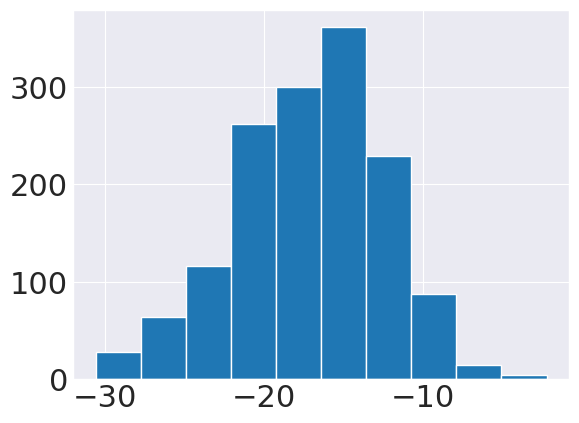

In [91]:
data_df["mfe"].hist()

In [92]:
data_df[data_df["mfe"] > -20]["gene_id"].value_counts()

gene_id
JMY      742
PXDN     143
RMI2      50
NRN1      50
NTN1      30
TOB2      27
RRAGA     26
GNA11      3
Name: count, dtype: int64

In [93]:
data_df = data_df[data_df["mfe"] > -20]

In [94]:
data_df["tm_max"].describe()

count    1071.000000
mean       71.467756
std         2.063264
min        64.607322
25%        70.105736
50%        71.635180
75%        73.062997
max        74.997211
Name: tm_max, dtype: float64

<Axes: >

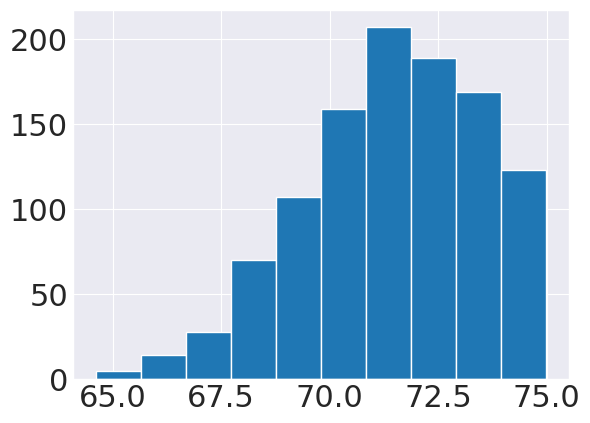

In [95]:
data_df["tm_max"].hist()

<Axes: >

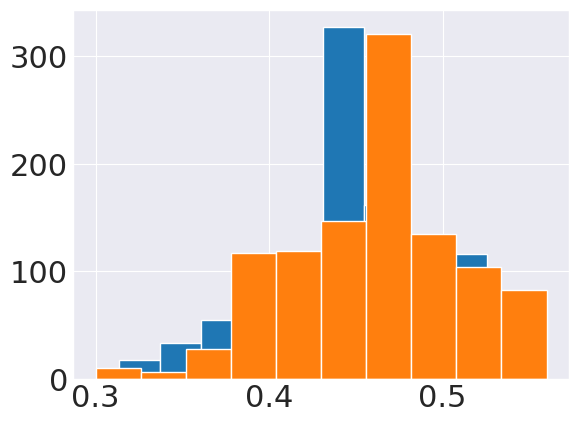

In [96]:
data_df["up_gc"] = data_df["up_probe_30"].apply(lambda x: (x.count("G")+x.count("C"))/len(x))
data_df["down_gc"] = data_df["down_probe_30"].apply(lambda x: (x.count("G")+x.count("C"))/len(x))
data_df["up_gc"].hist()
data_df["down_gc"].hist()

In [97]:
data_df = data_df[(data_df["up_gc"] > 0.4) & (data_df["down_gc"] > 0.4)]
data_df["gene_id"].value_counts()

gene_id
JMY      489
PXDN     133
RMI2      49
NRN1      49
RRAGA     26
NTN1      20
TOB2      17
GNA11      2
Name: count, dtype: int64

In [103]:
cand_list = []
for gene_id in data_df["gene_id"].unique():
    gene_df = data_df[data_df["gene_id"] == gene_id].copy()
    gene_df = gene_df.sort_values("tm_max")
    gene_df = gene_df.iloc[:20]
    cand_list.append(gene_df)
cand_df = pd.concat(cand_list)

In [104]:
print(cand_df)

            label_id gene_id  log_pm6a       dom  dom_label  label  count_dom  \
464   NM_002067:3932   GNA11  0.008714  0.041363        0.0      0        411   
463   NM_002067:3930   GNA11 -0.000000  0.007229        0.0      0        415   
1815  NM_152405:6754     JMY -0.000000  0.031250        0.0      0         64   
1821  NM_152405:6743     JMY  0.000000  0.000000        0.0      0         66   
1822  NM_152405:6742     JMY -0.000000  0.015625        0.0      0         64   
...              ...     ...       ...       ...        ...    ...        ...   
5998  NM_016272:3984    TOB2 -0.000000  0.034632        0.0      0        231   
6120  NM_016272:2185    TOB2 -0.000000  0.011976        0.0      0        167   
6003  NM_016272:3985    TOB2 -0.000000  0.008299        0.0      0        241   
6074  NM_016272:3986    TOB2 -0.000000  0.012821        0.0      0        234   
6000  NM_016272:3978    TOB2  0.042581  0.046414        0.0      0        237   

      count_all   5mer  dra

In [108]:
up_fasta = "\n".join([f">{label_id}\n{seq[-30:]}" for label_id, seq in zip(cand_df["label_id"], cand_df["up_probe_30"])])
down_fasta = "\n".join([f">{label_id}\n{seq[:30]}" for label_id, seq in zip(cand_df["label_id"], cand_df["down_probe_30"])])



In [109]:
print(up_fasta)

>NM_002067:3932
ATTAAGGTTGAAATTGTCTGAAATCAGGAC
>NM_002067:3930
TAAGGTTGAAATTGTCTGAAATCAGGACTG
>NM_152405:6754
TTACATAGAGTAAGTCAAAGTGCTGAAAAT
>NM_152405:6743
AAGTCAAAGTGCTGAAAATTATTTTCTGGT
>NM_152405:6742
AGTCAAAGTGCTGAAAATTATTTTCTGGTT
>NM_152405:6747
GAGTAAGTCAAAGTGCTGAAAATTATTTTC
>NM_152405:6739
CAAAGTGCTGAAAATTATTTTCTGGTTTTG
>NM_152405:3954
GACTTACAGCTATCATGATGATAAACTTTC
>NM_152405:8427
CAATGAGAAATTCAATGAAACAATGGAGAT
>NM_152405:2139
TAACTCTTCACACTTCAAGATTTCAAACTG
>NM_152405:8454
TTTGCACACTTGGAAAGACATATAATACAA
>NM_152405:4104
CCATGTTAAATGTATCATGTTGTGAACATA
>NM_152405:8425
ATGAGAAATTCAATGAAACAATGGAGATTC
>NM_152405:8459
TATAGTTTGCACACTTGGAAAGACATATAA
>NM_152405:6755
ATTACATAGAGTAAGTCAAAGTGCTGAAAA
>NM_152405:5635
ACAGGACATATGTATAAAATGAGCCTATTT
>NM_152405:2135
TCTTCACACTTCAAGATTTCAAACTGTACT
>NM_152405:6370
TAATCTCAAAATGTCCCAAACTCATTTACT
>NM_152405:3985
TTAGGTGTATTTCCATTTGATTTTAATGCC
>NM_152405:6994
GTGTCTTAGGGAATGTGTAAAATTAAATTG
>NM_152405:2132
TCACACTTCAAGATTTCAAACTGTACTTCA
>NM_152405:39

In [110]:
print(down_fasta)

>NM_002067:3932
GTGTAATATACAAGTATCACTGGGTCCCGT
>NM_002067:3930
GTAATATACAAGTATCACTGGGTCCCGTCC
>NM_152405:6754
ATTTTCTGGTTTTGTGTTATGAGAAAAGCT
>NM_152405:6743
TTGTGTTATGAGAAAAGCTCTACATTTCTA
>NM_152405:6742
TGTGTTATGAGAAAAGCTCTACATTTCTAT
>NM_152405:6747
GGTTTTGTGTTATGAGAAAAGCTCTACATT
>NM_152405:6739
GTTATGAGAAAAGCTCTACATTTCTATTCC
>NM_152405:3954
CAGAGTGTCACAGTATTTAATATAAGCTGA
>NM_152405:8427
CTGTCAAAGTTAAAGAACTCAGAAGTCACT
>NM_152405:2139
ACTTCATACAACTGAAGTTGCAGATCATAA
>NM_152405:8454
GAGAAATTCAATGAAACAATGGAGATTCTG
>NM_152405:4104
TAATAGATGTATCTCCATAAATGCAGCTTT
>NM_152405:8425
GTCAAAGTTAAAGAACTCAGAAGTCACTGT
>NM_152405:8459
ACAATGAGAAATTCAATGAAACAATGGAGA
>NM_152405:6755
TATTTTCTGGTTTTGTGTTATGAGAAAAGC
>NM_152405:5635
ATAATGAAATCCCAAAAGTAAAAGAGTAGC
>NM_152405:2135
CATACAACTGAAGTTGCAGATCATAATAAT
>NM_152405:6370
GTTTTACCTATTTTAAATGCATTGCAGTTG
>NM_152405:3985
GACTTACAGCTATCATGATGATAAACTTTC
>NM_152405:6994
ATTAATTGTATACTGATCCCATTCCAAACA
>NM_152405:2132
ACAACTGAAGTTGCAGATCATAATAATCAG
>NM_152405:39

In [111]:
blast_columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

up_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/select/blast_up_hits.csv",names=blast_columns)
down_blast_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/select/blast_down_hits.csv", names=blast_columns)

up_blast_df["qstrand"] = up_blast_df["qstart"] < up_blast_df["qend"]
up_blast_df["sstrand"] = up_blast_df["sstart"] < up_blast_df["send"]
up_blast_df = up_blast_df[up_blast_df["qstrand"] & up_blast_df["sstrand"]]

down_blast_df["qstrand"] = down_blast_df["qstart"] < down_blast_df["qend"]
down_blast_df["sstrand"] = down_blast_df["sstart"] < down_blast_df["send"]
down_blast_df = down_blast_df[down_blast_df["qstrand"] & down_blast_df["sstrand"]]

up_blast_df = up_blast_df[(up_blast_df["length"] >= 20)]
down_blast_df = down_blast_df[(down_blast_df["length"] >= 20)]
up_blast_df = up_blast_df[~((up_blast_df["length"] == 30) & (up_blast_df["pident"] == 100))]
down_blast_df = down_blast_df[~((down_blast_df["length"] == 30) & (down_blast_df["pident"] == 100))]

up_count = up_blast_df.groupby("qseqid").count()["sseqid"]
up_count = up_count.reset_index()
up_count = up_count.rename(columns={"sseqid": "up_count", "qseqid": "label_id"})
down_count = down_blast_df.groupby("qseqid").count()["sseqid"]
down_count = down_count.reset_index()
down_count = down_count.rename(columns={"sseqid": "down_count", "qseqid": "label_id"})

In [112]:
neg_blast_df = cand_df.merge(up_count, on="label_id", how="left").merge(down_count, on="label_id", how="left")
neg_blast_df.fillna(0, inplace=True)
neg_blast_df["blast_hit"] = neg_blast_df["up_count"] + neg_blast_df["down_count"]
neg_blast_df = neg_blast_df[(neg_blast_df["blast_hit"] == 0)]
neg_blast_df

,label_id,gene_id,log_pm6a,dom,dom_label,label,count_dom,count_all,5mer,drach,...,down_probe_30,tm_max,seq,has_repeat,mfe,up_gc,down_gc,up_count,down_count,blast_hit
3,NM_152405:6743,JMY,0.000000,0.000000,0.0,0,66,66,AAAAC,False,...,TTGTGTTATGAGAAAAGCTCTACATTTCTACAGAGGCTGAGTCGCT...,67.946998,CACAGCTGTAATAGTGGGAATAGAAATGTAGAGCTTTTCTCATAAC...,False,-10.8,0.411765,0.42,0.0,0.0,0.0
4,NM_152405:6742,JMY,-0.000000,0.015625,0.0,0,64,65,CAAAA,False,...,TGTGTTATGAGAAAAGCTCTACATTTCTATCAGAGGCTGAGTCGCT...,67.946998,ACACAGCTGTAATAGTGGGAATAGAAATGTAGAGCTTTTCTCATAA...,False,-10.8,0.411765,0.42,0.0,0.0,0.0
6,NM_152405:6739,JMY,0.000000,0.000000,0.0,0,63,64,ACACA,False,...,GTTATGAGAAAAGCTCTACATTTCTATTCCCAGAGGCTGAGTCGCT...,67.972368,TAGACACAGCTGTAATAGTGGGAATAGAAATGTAGAGCTTTTCTCA...,False,-10.2,0.411765,0.44,0.0,0.0,0.0
7,NM_152405:3954,JMY,-0.000000,0.085714,0.0,0,35,37,TGAGA,False,...,CAGAGTGTCACAGTATTTAATATAAGCTGACAGAGGCTGAGTCGCT...,67.992350,AAAAAATAGCTTCTTCCATATCAGCTTATATTAAATACTGTGACAC...,False,-10.0,0.431373,0.44,0.0,0.0,0.0
8,NM_152405:8427,JMY,0.000000,0.000000,0.0,0,99,100,AGAAT,False,...,CTGTCAAAGTTAAAGAACTCAGAAGTCACTCAGAGGCTGAGTCGCT...,68.066903,GTAAATGATGCTACCCATACAGTGACTTCTGAGTTCTTTAACTTTG...,False,-11.2,0.411765,0.46,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NM_016272:3984,TOB2,-0.000000,0.034632,0.0,0,231,245,ACAAA,False,...,GTTCCTGGGAAAGAGGGATAGATAGAGGATCAGAGGCTGAGTCGCT...,72.704253,ACCTTTTCTCCCCTTTCCCCATCCTCTATCTATCCCTCTTTCCCAG...,False,-11.5,0.411765,0.52,0.0,0.0,0.0
135,NM_016272:2185,TOB2,-0.000000,0.011976,0.0,0,167,176,CTAGT,False,...,AGACGAAGTGCTAATCTCCCTGTAGTCACACAGAGGCTGAGTCGCT...,72.862080,CTCCCCCTGGAGCTGATGTCTGTGACTACAGGGAGATTAGCACTTC...,False,-18.9,0.509804,0.52,0.0,0.0,0.0
136,NM_016272:3985,TOB2,-0.000000,0.008299,0.0,0,241,251,CAAAT,False,...,TGTTCCTGGGAAAGAGGGATAGATAGAGGACAGAGGCTGAGTCGCT...,73.455716,CCTTTTCTCCCCTTTCCCCATCCTCTATCTATCCCTCTTTCCCAGG...,False,-11.3,0.431373,0.52,0.0,0.0,0.0
137,NM_016272:3986,TOB2,-0.000000,0.012821,0.0,0,234,249,AAATC,False,...,TTGTTCCTGGGAAAGAGGGATAGATAGAGGCAGAGGCTGAGTCGCT...,73.790414,CTTTTCTCCCCTTTCCCCATCCTCTATCTATCCCTCTTTCCCAGGA...,False,-11.5,0.450980,0.52,0.0,0.0,0.0


In [113]:
neg_blast_df["gene_id"].value_counts()

gene_id
NRN1     19
RRAGA    19
JMY      16
TOB2     16
NTN1     14
RMI2     12
PXDN      7
Name: count, dtype: int64

In [122]:
neg_blast_df.drop(columns=["up_probe_30", "down_probe_30", "seq"], inplace=True)
neg_blast_df.to_csv("/extdata4/baeklab/Hyeonseo/m6A/select/neg_blast.tsv", sep = "\t")